<div align="center">

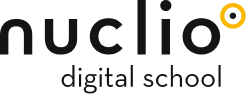

</div>

# Entregable 2 — Supervised Machine Learning
### Predicción de Churn — MobileNOW

**Nuclio Digital School**

**Integrantes:** Carmen Candial, Adrià Viñas, Juan Ceruso, Maximiliano Cifuentes

---

**Contexto de negocio.** MobileNOW, compañía de telecomunicaciones, atraviesa un descenso en su número de clientes activos tras varios trimestres con numerosas bajas. Para revertir esta tendencia, la compañía impulsa una campaña de retención dirigida a los clientes con mayor probabilidad de darse de baja, ofreciéndoles condiciones especiales a cambio de renovar su permanencia un año más.

**Nuestra misión como equipo de Data Science** es doble:
1. Modelizar la probabilidad de abandono (`churn = 1`) y calcular, para los 1.500 clientes preseleccionados, la probabilidad de darse de baja el próximo mes, de forma que la campaña de retención pueda priorizar a los clientes más propensos a abandonar.
2. Identificar qué factores tienen mayor impacto en la decisión de abandono, para poder actuar sobre ellos y combatir la fuga a largo plazo.

Se trata de un problema de **clasificación binaria**:
- `churn = 1` → el cliente se da de baja
- `churn = 0` → el cliente se queda

**Métrica principal: `f1-score`.** No utilizamos *accuracy* porque las clases no están perfectamente balanceadas y, sobre todo, porque nos interesa **detectar a los clientes que se van a fugar (recall) sin disparar demasiadas falsas alarmas (precision)**. El f1 combina ambos aspectos y es, además, la métrica sobre la que se evalúa este entregable.

**En este notebook entregamos:**
1. El modelo entrenado, validado y guardado.
2. La predicción sobre el 100% de los clientes a predecir, exportada a CSV.
3. La interpretación de las variables que más influyen en la fuga.

A lo largo del notebook justificamos el porqué de cada decisión tomada, no solo el código.

# 0. Configuración del entorno

Instalación de las dependencias y definición de la ruta donde se encuentran los ficheros de datos.

In [1]:
# Dependencias
# Nota: xgboost se fija en 1.7.6 porque las versiones >=2.0 cambian el formato
# interno de base_score y rompen shap.TreeExplainer (ValueError al hacer SHAP).
# Nota: scikit-learn se fija en <1.6 porque esa versión introdujo la nueva API
# de "tags" (__sklearn_tags__), que xgboost==1.7.6 no implementa -> VotingClassifier
# rompe con AttributeError: 'super' object has no attribute '__sklearn_tags__'.
%pip install -q pandas numpy matplotlib seaborn "scikit-learn<1.6" joblib openpyxl
%pip install -q imbalanced-learn "xgboost==1.7.6" catboost shap

# Carpeta donde están los ficheros de datos.
# Usamos "." porque el notebook y los CSV/XLSX viven en la misma carpeta
# (tanto en local como si se sube todo junto a Colab/Drive).
from pathlib import Path
RUTA = Path(".")


Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + meson setup C:\Users\Carmen\AppData\Local\Temp\pip-install-4nb2e_x9\scikit-learn_a58258efaeeb4ad59d17228fdce967ec C:\Users\Carmen\AppData\Local\Temp\pip-install-4nb2e_x9\scikit-learn_a58258efaeeb4ad59d17228fdce967ec\.mesonpy-zdp_heiv -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Carmen\AppData\Local\Temp\pip-install-4nb2e_x9\scikit-learn_a58258efaeeb4ad59d17228fdce967ec\.mesonpy-zdp_heiv\meson-python-native-file.ini
      The Meson build system
      Version: 1.11.1
      Source dir: C:\Users\Carmen\AppData\Local\Temp\pip-install-4nb2e_x9\scikit-learn_a58258efaeeb4ad59d17228fdce967ec
      Build dir: C:\Users\Carmen\AppData\Local\Temp\pip-install-4nb2e_x9\scikit-learn_a58258efaeeb4ad59d17228fdce967ec\.mesonpy-zdp_heiv
      Build type: native build
      Project name: scikit-learn
      Project ver

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Imports

Cargamos las librerías necesarias: gestión de datos, visualización, preprocessing, los modelos de clasificación (incluidos XGBoost y CatBoost), SHAP para interpretabilidad y las utilidades de métricas y persistencia.

In [2]:
# --- gestión de datos ---
import pandas as pd
import numpy as np

# --- gráficos ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- preprocessing y validación ---
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold, KFold,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- pipeline reutilizable (fit solo en train) ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config

# --- rebalanceo ---
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling  import SMOTE

# --- modelos lineales ---
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# --- modelos de árbol / boosting / ensemble ---
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              HistGradientBoostingClassifier,
                              VotingClassifier)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# --- interpretabilidad ---
import shap

# --- métricas y persistencia ---
from sklearn import metrics
import joblib

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Librerías cargadas correctamente.")

c:\Users\Carmen\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Función `pretty_table`

Para mantener el mismo criterio visual que usamos en el Entregable 1, definimos una función auxiliar que aplica un formato consistente (encabezado oscuro, filas alternadas, alineación centrada) a cualquier tabla que mostremos a lo largo del notebook.

In [3]:
def pretty_table(df, precision=2):
    """Devuelve una tabla estilizada para mejorar la lectura en el notebook."""
    return (
        df.style
        .format(precision=precision, thousands=",")
        .set_properties(**{
            "text-align": "center",
            "padding": "8px",
            "border": "1px solid #dbeafe"
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#0b1f3a"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "10px"),
                ("border", "1px solid #dbeafe")
            ]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#e0f2fe")]},
            {"selector": "tbody tr:nth-child(odd)",  "props": [("background-color", "#ffffff")]}
        ])
    )

print("pretty_table definida.")

pretty_table definida.


Cargamos los tres ficheros: el de **entrenar** (incluye la columna `churn`), el de **predecir** (sin `churn`: son los clientes sobre los que tendremos que decidir) y el **diccionario** de variables.

In [4]:
# carpeta de los datos (debe coincidir con la del setup)
from pathlib import Path
RUTA = Path(".")

df_entrenar   = pd.read_csv(RUTA / "churn - dataset a entrenar.csv")
df_predecir   = pd.read_csv(RUTA / "churn - dataset a predecir.csv")
df_diccionario = pd.read_excel(RUTA / "churn - diccionario de variables.xlsx")


ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
display(pretty_table(df_entrenar.head()))

,rev,mou,totmrc,ovrmou,ovrrev,vceovr,roam,change_mou,change_rev,drop_vce,blck_vce,blck_dat,unan_vce,plcd_vce,recv_vce,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callwait,churn,months,uniqsubs,actvsubs,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,marital,infobase,income,numbcars,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,24.00,219.25,22.50,0.00,0.00,0.00,0.00,-157.25,-19.00,0.67,0.67,0.00,6.33,52.33,42.33,45.00,0.00,0.00,0.00,0.00,18.00,0.00,90.64,97.18,0.00,0.00,0.00,0.00,58.00,0.00,132.60,24.00,0.00,55.22,0.00,1.33,52.33,45.00,0.33,1,61,2,1,A,N,"1,652","4,228.00","1,504.62","1,453.44","4,085.00","1,602",29.66,83.37,32.69,272,116,30,322.00,136.00,38.00,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.99,2.00,2.00,WCMB,0.00,0.00,O,15.00,S,M,4.00,3.00,0.00,N,U,U,U,U,U,Y,361.00,"1,000,001"
1,55.23,570.50,71.98,0.00,0.00,0.00,0.00,38.50,0.00,9.67,0.67,0.00,77.00,222.33,94.67,137.00,0.00,8.67,15.00,11.08,66.00,0.00,285.23,106.33,14.67,10.82,0.67,0.37,97.33,0.00,173.48,90.33,0.00,218.09,0.00,10.33,222.33,137.00,0.00,0,57,1,1,A,N,"4,485","14,028.00","2,181.12","2,166.48","13,965.00","4,452",38.69,249.38,79.50,558,191,55,586.00,196.00,80.00,U,NEW ENGLAND AREA,Y,N,149.99,6.00,4.00,WCMB,0.00,0.00,R,5.00,S,M,6.00,1.00,0.00,I,U,U,U,U,U,Y,434.00,"1,000,005"
2,82.28,"1,312.25",75.00,0.00,0.00,0.00,0.00,156.75,8.14,52.00,7.67,0.00,76.00,702.00,365.00,577.33,0.00,4.33,11.00,7.75,301.67,1.33,369.54,200.32,370.33,243.21,147.00,85.15,555.67,0.00,382.10,303.67,0.00,187.76,0.00,59.67,702.00,577.33,22.67,0,59,2,2,C,N,"26,812","40,869.00","4,033.98","3,932.90","40,295.00","26,362",83.68,857.34,560.89,"1,260",960,80,"1,187.00",853.00,78.00,U,GREAT LAKES AREA,N,N,129.99,9.00,4.00,WCMB,0.00,0.00,O,1.00,S,M,6.00,1.00,0.00,U,U,U,U,U,U,Y,458.00,"1,000,006"
3,17.14,0.00,16.99,0.00,0.00,0.00,0.00,0.00,-0.15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,53,2,2,A,N,"6,279","17,390.03","3,091.70","3,065.24","17,371.03","6,271",58.95,334.06,120.60,0,0,17,0.00,0.00,17.00,C,DALLAS AREA,Y,N,29.99,4.00,3.00,nan,0.00,0.00,O,8.00,M,M,9.00,nan,0.00,N,U,U,U,U,U,Y,852.00,"1,000,007"
4,38.05,682.50,52.49,0.00,0.00,0.00,0.00,147.50,-3.06,9.00,1.67,0.00,13.00,97.00,13.00,73.33,0.00,0.67,5.33,5.28,5.00,0.00,470.02,42.20,6.67,6.23,0.00,0.00,33.33,0.00,81.07,53.00,0.00,431.15,0.00,10.67,97.00,73.33,0.67,0,53,1,1,B,N,"4,491","12,492.00","1,427.71","1,423.06","12,439.00","4,470",34.71,303.39,109.02,633,96,39,719.00,112.00,58.00,nan,nan,Y,N,79.99,3.00,2.00,WCMB,0.00,0.00,R,0.00,M,M,1.00,2.00,1.00,S,U,U,U,U,U,Y,231.00,"1,000,008"


In [ ]:
display(pretty_table(df_predecir.head()))

,rev,mou,totmrc,ovrmou,ovrrev,vceovr,roam,change_mou,change_rev,drop_vce,blck_vce,blck_dat,unan_vce,plcd_vce,recv_vce,comp_vce,comp_dat,custcare,ccrndmou,cc_mou,inonemin,threeway,mou_cvce,mou_rvce,owylis_vce,mouowylisv,iwylis_vce,mouiwylisv,peak_vce,peak_dat,mou_peav,opk_vce,opk_dat,mou_opkv,mou_opkd,drop_blk,attempt,complete,callwait,months,uniqsubs,actvsubs,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,marital,infobase,income,numbcars,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,31.45,56.00,30.00,8.75,1.45,1.45,0.00,-34.00,-1.45,1.00,0.00,0.00,2.00,14.33,12.00,11.67,0.00,0.00,0.00,0.00,6.33,0.00,5.37,12.70,0.00,0.00,1.00,1.32,2.33,0.00,1.41,21.00,0.00,16.67,0.00,1.00,14.33,11.67,0.00,55,1,1,A,N,"5,052","7,942.00","2,399.93","2,352.93","7,914.00","5,027",44.39,149.32,94.85,67,57,32,61.00,49.00,31.00,S,MIDWEST AREA,N,N,29.99,1.00,1.00,nan,0.00,0.00,O,10.00,M,M,7.00,3.00,0.00,G,U,U,U,Y,Y,Y,"1,646.00","1,000,055"
1,76.74,"1,007.75",59.99,65.25,19.57,19.57,6.68,-51.75,5.36,2.00,8.67,0.00,82.00,392.67,122.33,300.00,0.00,0.00,0.00,0.00,58.00,0.00,390.71,244.05,105.00,54.66,41.00,74.64,225.33,0.00,321.33,197.00,0.00,313.43,0.00,10.67,392.67,300.00,8.67,52,3,3,A,N,"12,566","23,282.00","2,805.23","2,749.73","23,077.00","12,472",53.92,452.49,244.55,"1,025",453,75,980.00,462.00,69.00,S,MIDWEST AREA,Y,R,29.99,7.00,5.00,WCMB,1.00,1.00,O,6.00,M,M,7.00,nan,0.00,D,U,U,U,U,U,Y,163.00,"1,000,081"
2,159.04,"2,542.50",75.00,458.25,45.83,45.83,9.56,-225.50,-19.36,34.33,3.00,0.00,178.00,926.67,514.33,725.67,0.00,0.33,3.00,2.77,257.67,0.00,920.44,765.30,285.33,385.75,129.67,257.12,"1,022.67",0.00,"1,476.83",159.33,0.00,208.91,0.00,37.33,926.67,725.67,50.00,48,5,4,A,N,"54,269","92,628.17","5,166.97","5,076.97","92,489.17","54,179",108.02,"1,967.85","1,152.74","2,618","1,508",166,"2,656.00","1,527.00",166.00,U,SOUTHWEST AREA,Y,N,29.99,8.00,6.00,WC,1.00,0.00,O,11.00,M,M,4.00,2.00,0.00,N,U,U,U,U,Y,Y,263.00,"1,000,301"
3,67.28,602.50,50.00,73.25,7.33,7.33,4.80,-155.50,-12.82,21.67,0.67,0.00,36.67,222.67,155.67,169.00,0.00,0.00,0.00,0.00,106.00,0.00,234.70,190.41,44.00,48.01,5.00,19.31,262.67,0.00,378.95,34.33,0.00,46.16,0.00,22.33,222.67,169.00,1.00,50,1,1,A,N,"23,357","47,230.00","4,478.24","4,386.30","46,840.00","23,149",91.38,975.83,482.27,654,317,71,"1,077.00",519.00,103.00,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,R,99.99,9.00,4.00,WCMB,0.00,0.00,O,10.00,S,M,2.00,1.00,0.00,N,U,U,U,U,U,Y,204.00,"1,000,444"
4,80.28,"1,245.25",68.30,73.00,18.25,18.25,0.00,-160.25,-62.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50,2,1,B,N,"66,754","122,300.50","6,847.28","6,748.76","121,786.50","66,511",140.60,"2,537.22","1,385.65","1,299",646,101,"1,423.00",682.00,99.00,U,SOUTH FLORIDA AREA,N,N,29.99,8.00,4.00,WC,0.00,0.00,O,1.00,A,M,6.00,2.00,0.00,S,U,U,U,U,U,Y,285.00,"1,000,449"


In [ ]:
display(pretty_table(df_diccionario.head(10)))

,Variable,Description
0,rev,Mean monthly revenue (charge amount)
1,mou,Mean number of monthly minutes of use
2,totmrc,Mean total monthly recurring charge
3,ovrmou,Mean overage minutes of use
4,ovrrev,Mean overage revenue
5,vceovr,Mean revenue of voice overage
6,roam,Mean number of roaming calls
7,change_mou,Percentage change in monthly minutes of use vs previous three month average
8,change_rev,Percentage change in monthly revenue vs previous three month average
9,drop_vce,Mean number of dropped (failed) voice calls


In [ ]:
print("Dataset entrenamiento:", df_entrenar.shape)
print("Dataset predicción:   ", df_predecir.shape)

Dataset entrenamiento: (50000, 86)
Dataset predicción:    (1500, 85)


In [ ]:
df_entrenar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 86 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rev               50000 non-null  float64
 1   mou               50000 non-null  float64
 2   totmrc            50000 non-null  float64
 3   ovrmou            50000 non-null  float64
 4   ovrrev            50000 non-null  float64
 5   vceovr            50000 non-null  float64
 6   roam              50000 non-null  float64
 7   change_mou        50000 non-null  float64
 8   change_rev        50000 non-null  float64
 9   drop_vce          50000 non-null  float64
 10  blck_vce          50000 non-null  float64
 11  blck_dat          50000 non-null  float64
 12  unan_vce          50000 non-null  float64
 13  plcd_vce          50000 non-null  float64
 14  recv_vce          50000 non-null  float64
 15  comp_vce          50000 non-null  float64
 16  comp_dat          50000 non-null  float6

Definimos dos constantes para no escribir los nombres a mano por todo el notebook.

In [ ]:
TARGET = "churn"          # variable objetivo
ID = "Customer_ID"        # clave primaria (no es una feature)

# 2. Business Understanding & EDA

Antes de tocar nada, miramos los datos para entender el problema:
- ¿Cómo está repartida la variable objetivo? (¿hay desbalanceo?)
- ¿Qué variables tienen nulos y cuántos?
- ¿Cuáles son numéricas y cuáles categóricas?

### 2.1 Distribución de la variable objetivo

Lo primero en cualquier clasificación: ver el reparto de clases. Si una clase fuera muy minoritaria (p. ej. 5%), tendríamos que ser muy cuidadosos con la métrica y el rebalanceo.

In [ ]:
vc_churn = df_entrenar[TARGET].value_counts().reset_index()
vc_churn.columns = ["churn", "count"]
display(pretty_table(vc_churn, precision=0))

,churn,count
0,0,"27,451"
1,1,"22,549"


In [ ]:
vc_churn_pct = (df_entrenar[TARGET].value_counts(normalize=True) * 100).reset_index()
vc_churn_pct.columns = ["churn", "% del total"]
display(pretty_table(vc_churn_pct, precision=2))

,churn,% del total
0,0,54.90
1,1,45.10


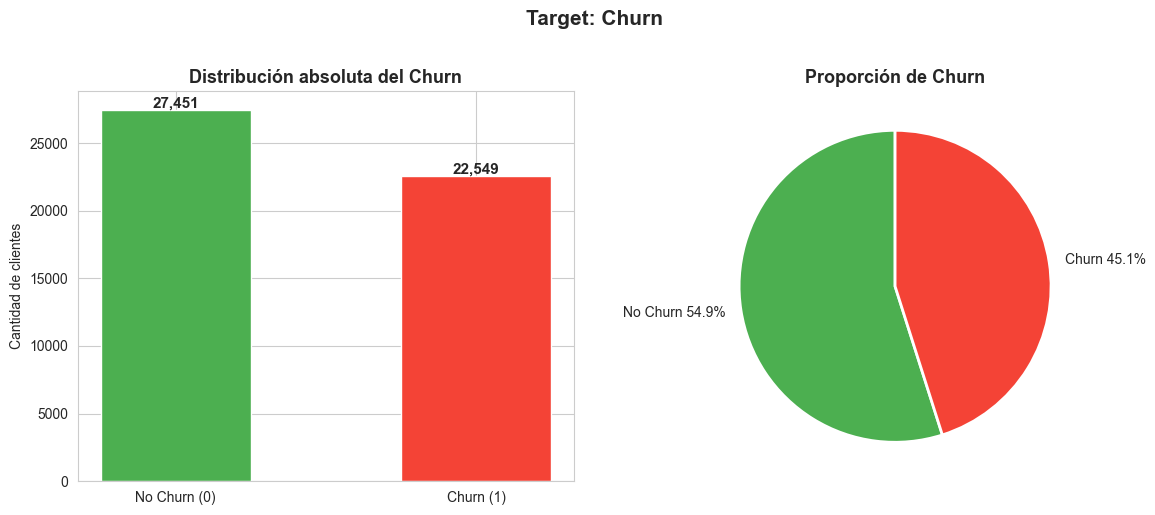


Clases: {0: np.int64(27451), 1: np.int64(22549)}
Ratio desbalance: 1.22:1
→ Dataset relativamente balanceado (45.1% churn).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df_entrenar[TARGET].value_counts().sort_index()
colors = ['#4CAF50', '#F44336']
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribución absoluta del Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
pct_vals = df_entrenar[TARGET].value_counts(normalize=True).sort_index().values * 100
labels = [f'No Churn {pct_vals[0]:.1f}%', f'Churn {pct_vals[1]:.1f}%']
axes[1].pie(pct_vals, labels=labels, colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')

plt.suptitle('Target: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClases: {dict(churn_counts)}")
print(f"Ratio desbalance: {churn_counts.iloc[0]/churn_counts.iloc[1]:.2f}:1")
print(f"→ Dataset relativamente balanceado ({pct_vals[1]:.1f}% churn).")

**Lectura.** El reparto es ~**55% (se quedan) / 45% (se van)**. Es un desbalanceo **muy suave**: las clases están casi igualadas. Esto significa que:
- El *accuracy* base de predecir siempre "se queda" sería solo ~55%, así que cualquier modelo decente debería superarlo con holgura.
- El rebalanceo (más adelante) tendrá un efecto pequeño, pero lo aplicamos igualmente para igualar exactamente las clases en el entrenamiento.

### 2.2 Nulos

Calculamos el % de nulos por columna y lo ordenamos. Saber el volumen de nulos decide la estrategia: pocos → se pueden eliminar filas; muchos → hay que imputar (o incluso descartar la variable).

In [ ]:
nulos = (df_entrenar.isnull().mean().sort_values(ascending=False) * 100)
nulos_tbl = nulos[nulos > 0].reset_index()
nulos_tbl.columns = ["variable", "% nulos"]
display(pretty_table(nulos_tbl, precision=2))

,variable,% nulos
0,numbcars,46.96
1,ownrent,30.89
2,lor,27.43
3,income,22.62
4,infobase,19.58
5,hnd_webcap,9.94
6,prizm_social_one,6.58
7,area,1.44


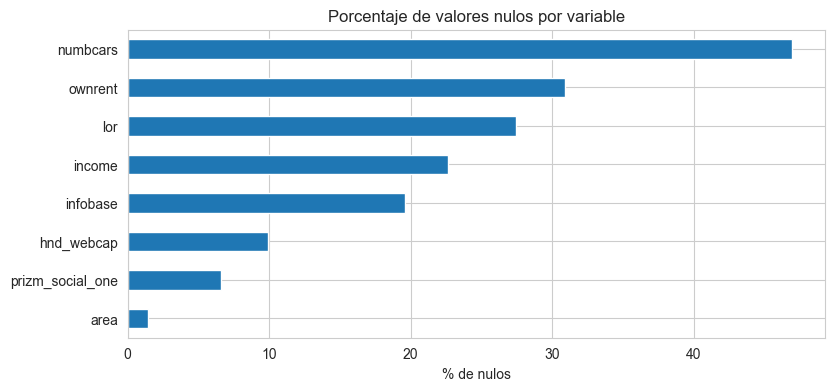

In [ ]:
nulos[nulos > 0].sort_values().plot(kind="barh", figsize=(9,4))
plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("% de nulos")
plt.show()

**Lectura.** Solo **8 columnas** tienen nulos. Las más afectadas son `numbcars` (~47%), `ownrent` (~31%), `lor` (~27%), `income` (~23%) e `infobase` (~20%). Son variables **socio-demográficas** (provienen de un enriquecimiento externo, por eso faltan tanto). No las eliminamos a la ligera porque pueden aportar señal; las **imputaremos** en preprocessing.

### 2.3 Tipos de variable: numéricas vs categóricas

In [ ]:
cat_cols = df_entrenar.select_dtypes(include="object").columns.tolist()
num_cols = df_entrenar.select_dtypes(include=["int64","float64"]).columns.tolist()
print(f"Categóricas ({len(cat_cols)}):", cat_cols)
print(f"\nNuméricas: {len(num_cols)}")

Categóricas (17): ['crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'marital', 'infobase', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Numéricas: 69


In [ ]:
# cardinalidad de las categóricas: ¿cuántos valores distintos tiene cada una?
card_cat = df_entrenar[cat_cols].nunique().sort_values().reset_index()
card_cat.columns = ["variable", "valores_unicos"]
display(pretty_table(card_cat, precision=0))

,variable,valores_unicos
0,infobase,1
1,creditcd,2
2,asl_flag,2
3,kid11_15,2
4,kid6_10,2
5,refurb_new,2
6,hnd_webcap,2
7,ownrent,2
8,kid16_17,2
9,kid3_5,2


**Lectura.**
- La mayoría de categóricas son **binarias** (`asl_flag`, `creditcd`, los `kid*`…).
- `infobase` tiene **un solo valor** ('M') → es una **constante**, no aporta nada y la eliminaremos.
- `crclscod` (51 categorías), `area` (19) y `ethnic` (16) tienen **cardinalidad alta**: hacerles *one-hot* generaría decenas de columnas dummy poco pobladas. En preprocessing las trataremos con **target encoding** en vez de one-hot, para quedarnos con una sola columna numérica por variable.

### 2.4 Análisis univariable rápido

Vemos cómo se reparten las clases de `churn` dentro de algunas variables binarias y describimos las numéricas.

In [ ]:
# variables numéricas "reales" (más de 2 valores) descritas
num_reales = [c for c in num_cols if df_entrenar[c].nunique() > 2 and c != TARGET]
display(pretty_table(df_entrenar[num_reales].describe().T.head(15), precision=2))

,count,mean,std,min,25%,50%,75%,max
rev,"50,000.00",59.59,49.44,0.89,33.25,48.19,71.58,"3,843.26"
mou,"50,000.00",525.93,541.54,0.00,155.50,361.75,719.25,"12,206.75"
totmrc,"50,000.00",46.76,24.14,-26.91,30.00,44.99,59.99,409.99
ovrmou,"50,000.00",42.25,102.90,0.00,0.00,2.50,41.25,"4,320.75"
ovrrev,"50,000.00",13.68,31.59,0.00,0.00,0.88,13.90,890.76
vceovr,"50,000.00",13.42,31.23,0.00,0.00,0.48,13.50,890.76
roam,"50,000.00",1.38,19.09,0.00,0.00,0.00,0.26,"3,685.20"
change_mou,"50,000.00",-14.12,292.67,"-3,406.50",-85.50,-6.25,62.75,"31,219.25"
change_rev,"50,000.00",-1.28,59.35,"-1,107.74",-7.32,-0.32,1.48,"9,963.66"
drop_vce,"50,000.00",6.05,9.18,0.00,0.67,3.00,7.67,232.67


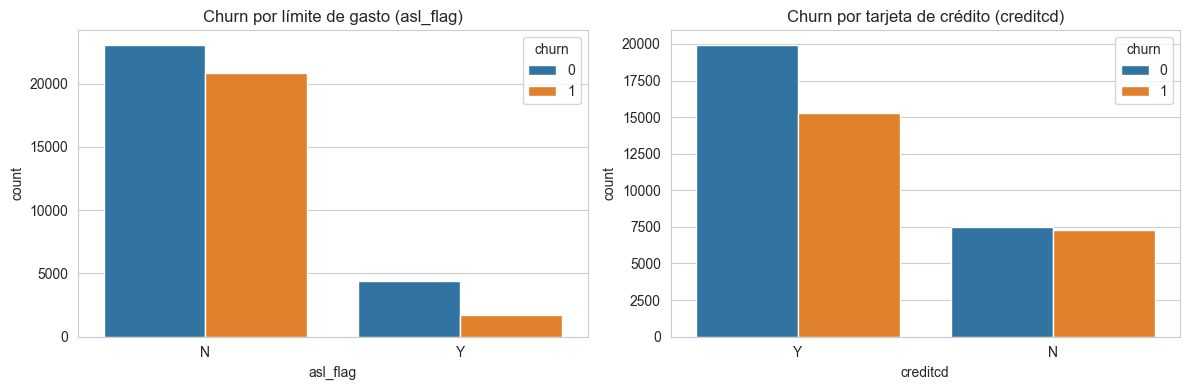

In [ ]:
# relación de un par de categóricas con el churn
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(data=df_entrenar, x="asl_flag", hue=TARGET, ax=axes[0])
axes[0].set_title("Churn por límite de gasto (asl_flag)")
sns.countplot(data=df_entrenar, x="creditcd", hue=TARGET, ax=axes[1])
axes[1].set_title("Churn por tarjeta de crédito (creditcd)")
plt.tight_layout(); plt.show()

**Distribución y outliers de las variables numéricas.** Para cada variable pintamos el **histograma (con KDE)** —que muestra la forma de la distribución— y el **boxplot** —que destaca los outliers—. El título lo sacamos del **diccionario de variables** para que se lea su significado.

Variables numéricas más relacionadas con el churn: ['eqpdays', 'hnd_price', 'totmrc', 'models', 'phones', 'mou']


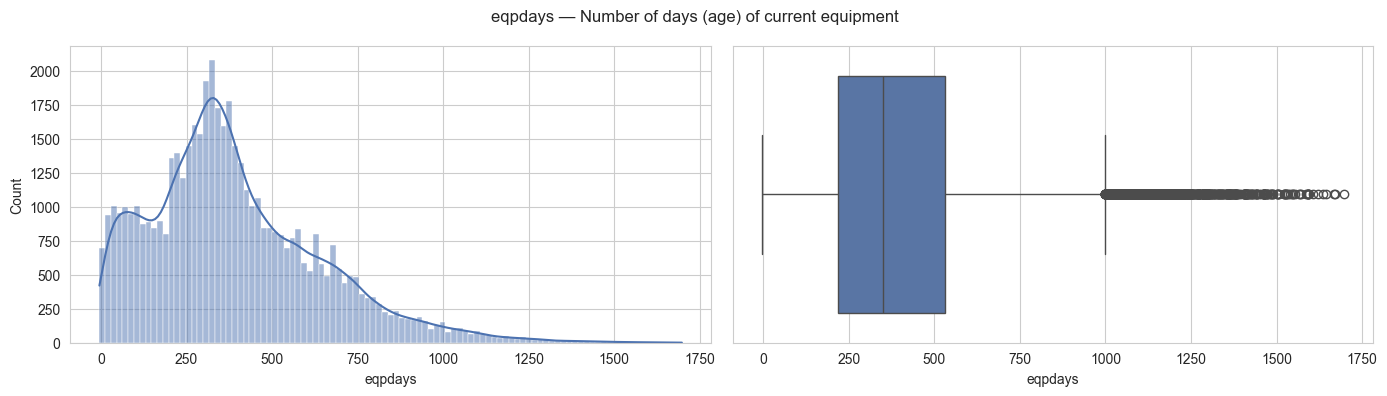

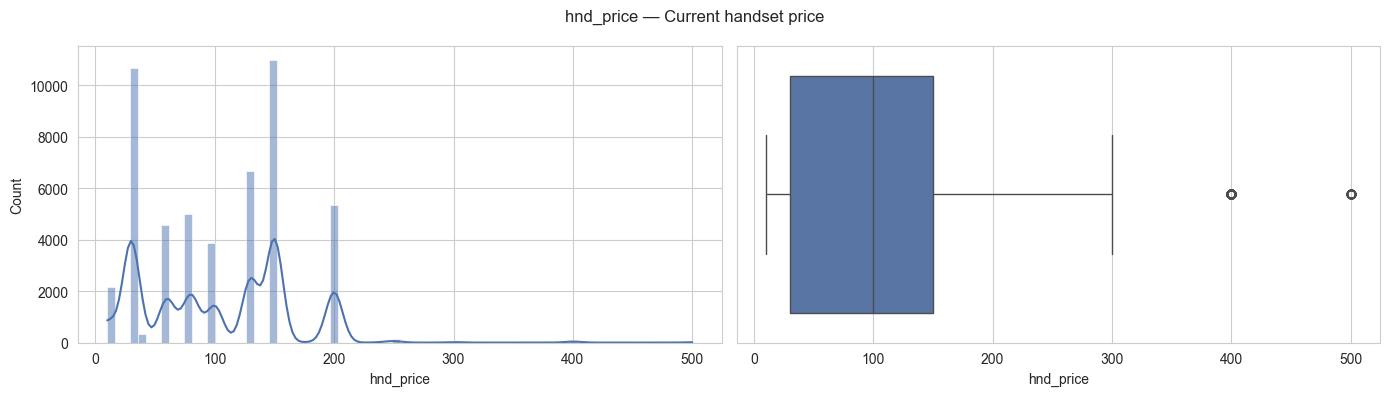

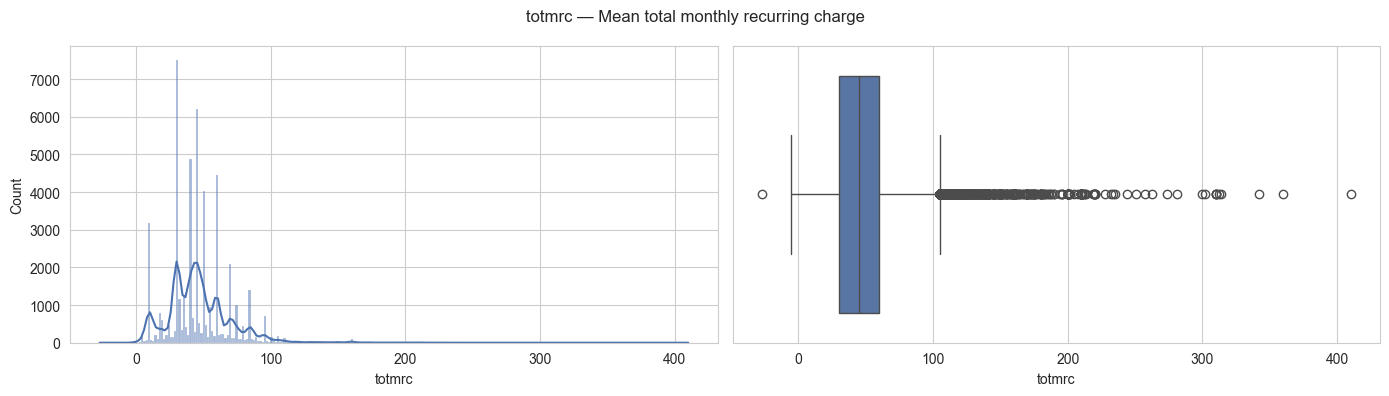

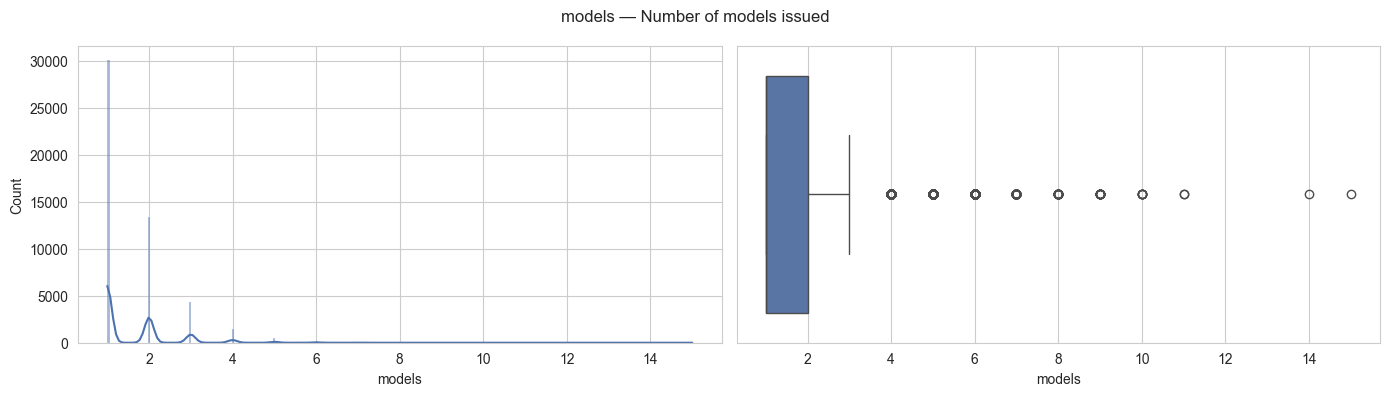

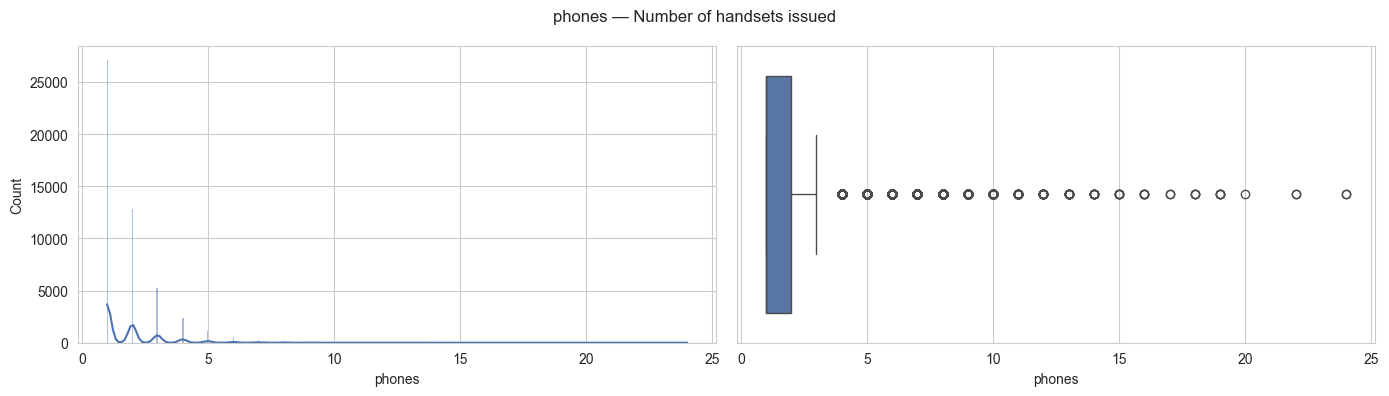

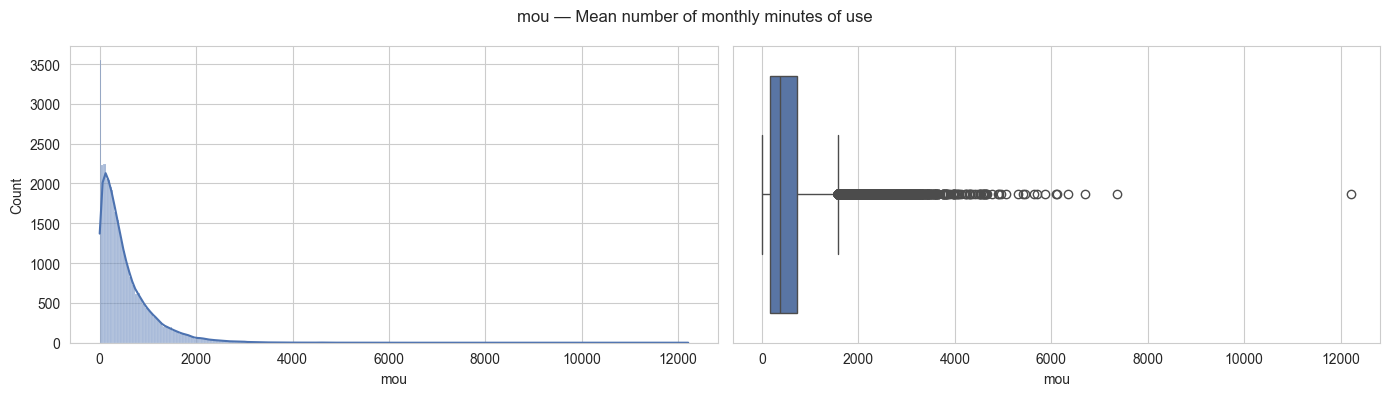

In [ ]:
# diccionario {nombre_variable: descripción} a partir del Excel
diccionario = dict(zip(df_diccionario["Variable"], df_diccionario["Description"]))

# elegimos AUTOMÁTICAMENTE las numéricas más correlacionadas con el churn (top 6 por |corr|)
num_feats = [c for c in num_cols if c != TARGET]
corr_target = df_entrenar[num_feats + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
top_num_vars = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
print("Variables numéricas más relacionadas con el churn:", top_num_vars)

for num in top_num_vars:
    titulo = diccionario.get(num, num)
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
    sns.histplot(data=df_entrenar, x=num, ax=ax[0], kde=True, color="#4c72b0")
    sns.boxplot(data=df_entrenar, x=num, ax=ax[1], color="#4c72b0")
    fig.suptitle(f"{num} — {titulo}", fontsize=12)
    plt.tight_layout()
    plt.show()

**Lectura.** Casi todas las variables de uso/gasto (`mou`, `rev`, `totmrc`…) están **sesgadas a la derecha** y con **outliers** por la cola alta (clientes con consumos muy grandes). Por eso en preprocessing imputamos con **mediana** (robusta a esos outliers) en vez de media. Los boxplots confirman que no son errores, sino cola larga natural del negocio.

### 2.5 Relación de las variables numéricas con el churn

Para ver qué variables numéricas separan a los clientes que se van de los que se quedan, miramos su **correlación con `churn`** (rojo = a más valor, más fuga; azul = a más valor, menos fuga) y la **distribución de las más relevantes** según se queden o se vayan.

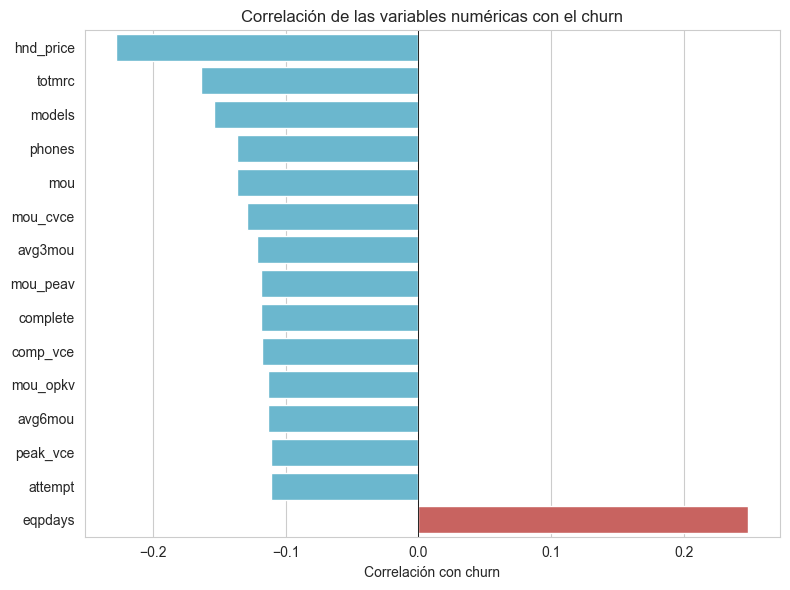

In [ ]:
# correlación de cada variable numérica con la target (top 15 por valor absoluto)
num_feats = [c for c in num_cols if c != TARGET]   # numéricas sin la propia target
corr_target = df_entrenar[num_feats + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
top_corr = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index).head(15).sort_values()

plt.figure(figsize=(8,6))
colores = ['#d9534f' if v > 0 else '#5bc0de' for v in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, palette=colores)
plt.axvline(0, color='black', linewidth=0.6)
plt.title("Correlación de las variables numéricas con el churn")
plt.xlabel("Correlación con churn"); plt.ylabel("")
plt.tight_layout(); plt.show()

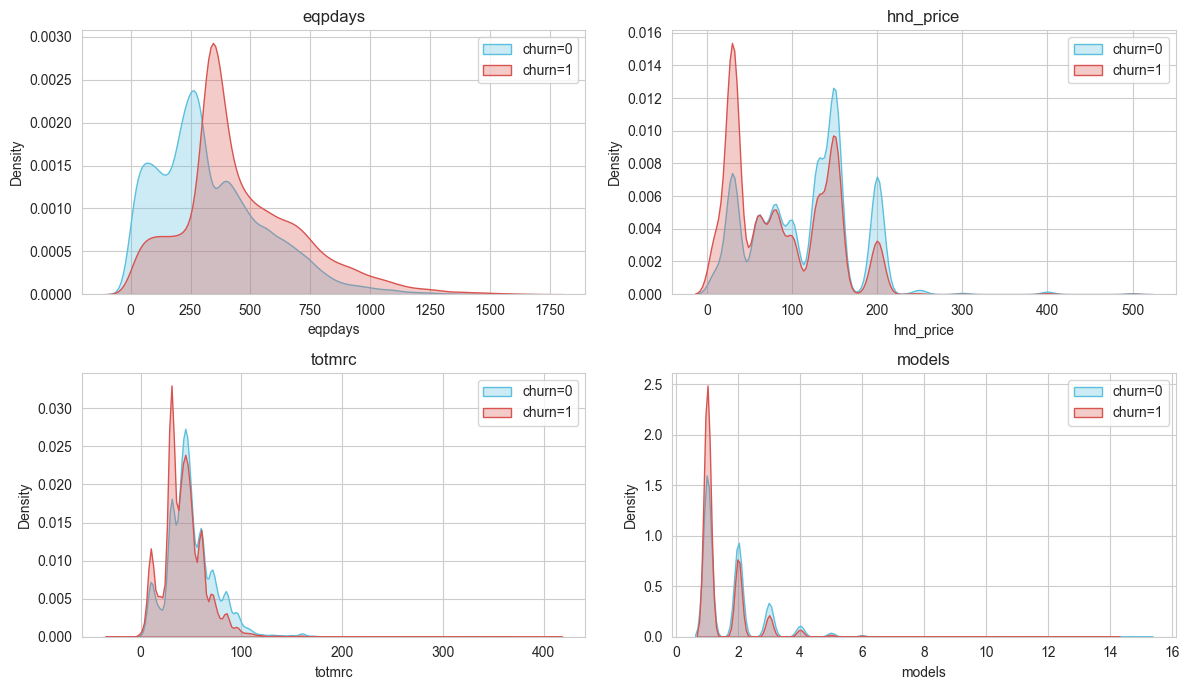

In [ ]:
# distribución según churn (0 vs 1) de las 4 variables más correlacionadas
top_vars = top_num_vars[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), top_vars):
    for clase, color in [(0, "#5bc0de"), (1, "#d9534f")]:
        sns.kdeplot(df_entrenar.loc[df_entrenar[TARGET]==clase, col].dropna(),
                    ax=ax, label=f"churn={clase}", fill=True, alpha=0.3, color=color)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

**Lectura.**
- **`eqpdays`** (antigüedad del equipo) es la variable con **correlación positiva** más fuerte: los churners (rojo) se concentran en equipos más viejos. Tiene sentido — un móvil antiguo invita a cambiar de compañía.
- **`hnd_price`, `totmrc`, `mou`** tienen correlación **negativa**: clientes con terminal más caro, mayor cargo recurrente y más minutos de uso se fugan menos (están más "enganchados" al servicio).
- Las correlaciones individuales son moderadas (|r| < 0.25): **ninguna variable sola explica el churn**, hará falta combinar muchas (por eso ganarán los modelos de árbol que capturan interacciones).

### 2.5.1 Distribución de **todas** las variables numéricas según churn

Repetimos el análisis anterior pero con **todas** las variables numéricas, no solo las más correlacionadas. El objetivo es de **selección de variables**: detectar visualmente cuáles separan las clases (las dos curvas se distinguen) y cuáles no aportan nada (las curvas de `churn=0` y `churn=1` se solapan por completo), que serían candidatas a eliminar.

Graficando 64 variables numéricas


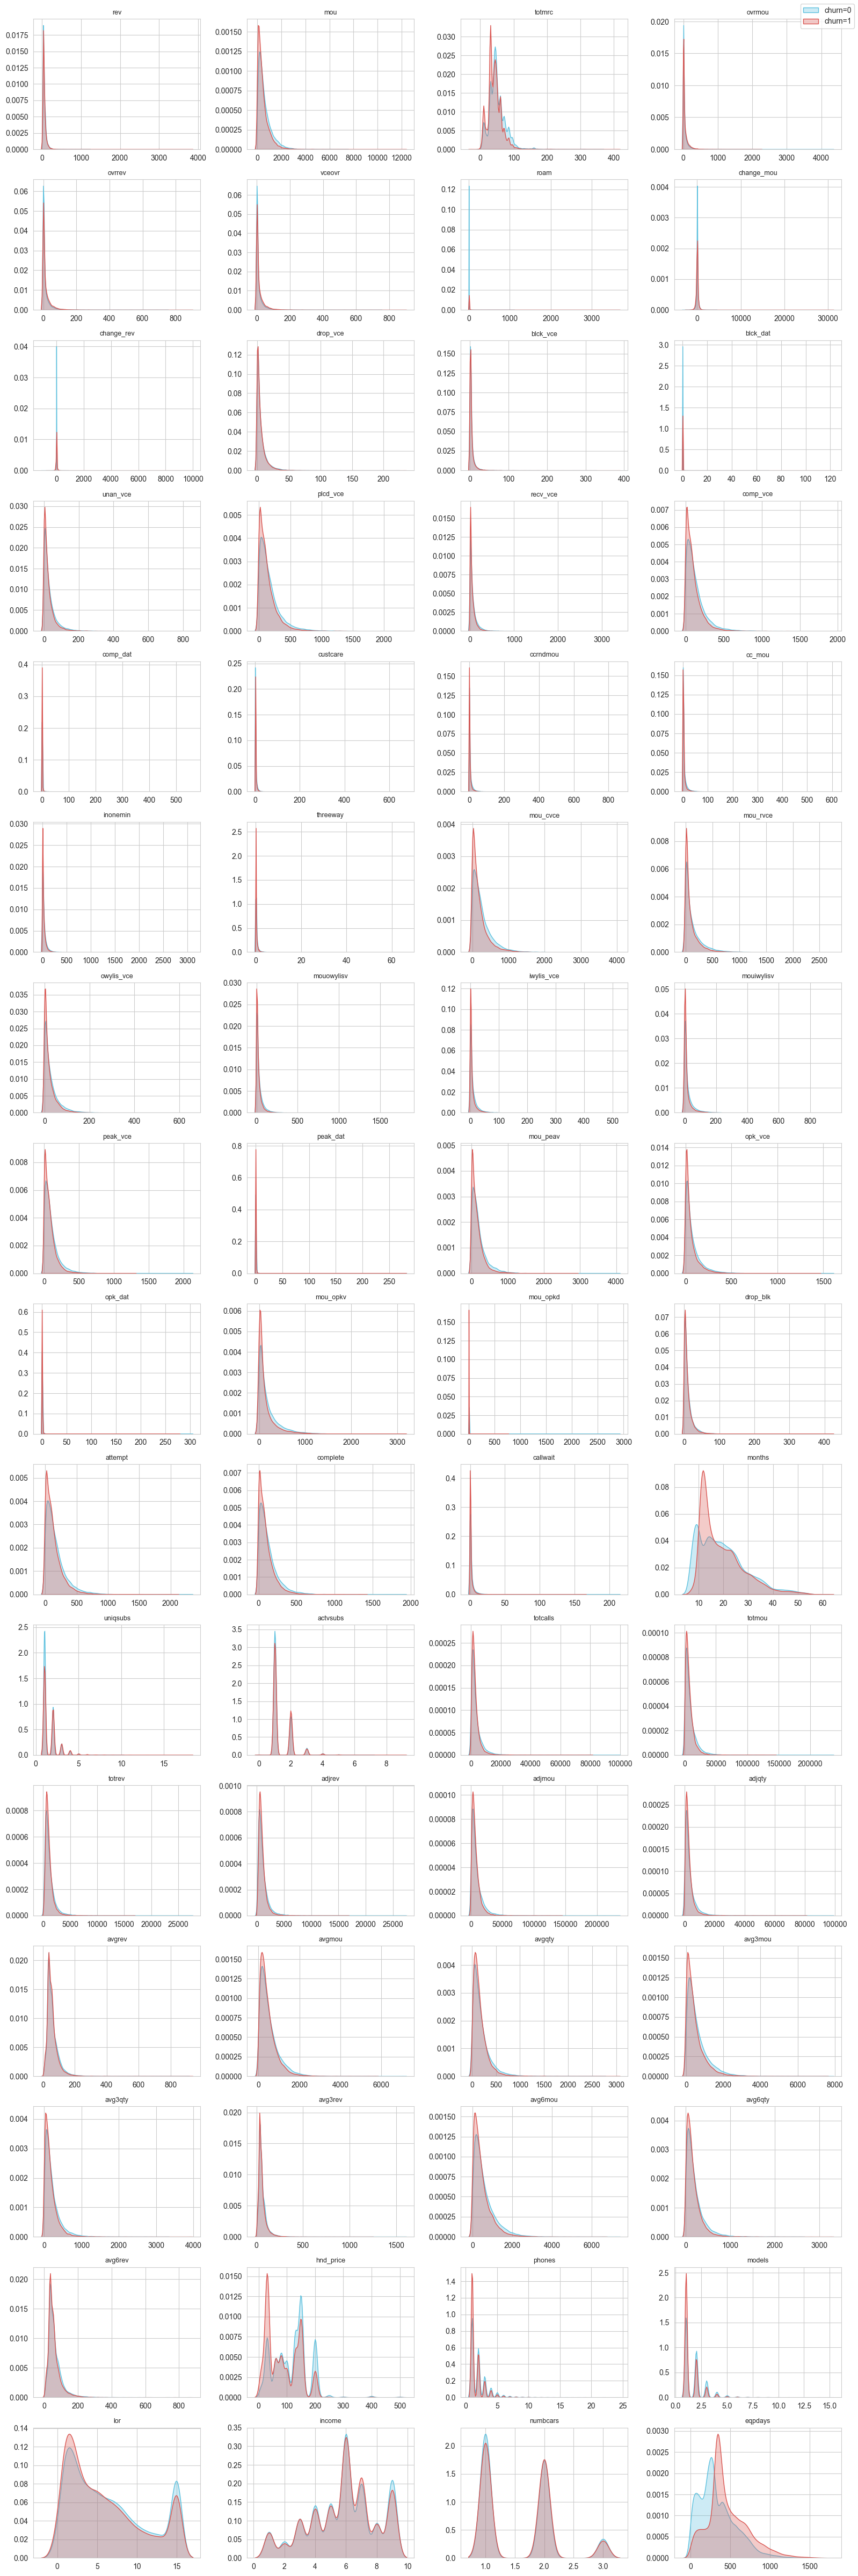

In [ ]:
# todas las numéricas "reales" (más de 2 valores, sin la target ni el ID)
num_kde = [c for c in num_cols if df_entrenar[c].nunique() > 2 and c not in [TARGET, ID]]
print(f"Graficando {len(num_kde)} variables numéricas")

ncols = 4
nrows = (len(num_kde) + ncols - 1) // ncols          # techo de la división
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.ravel()

for i, col in enumerate(num_kde):
    for clase, color in [(0, "#5bc0de"), (1, "#d9534f")]:
        sns.kdeplot(df_entrenar.loc[df_entrenar[TARGET] == clase, col].dropna(),
                    ax=axes[i], fill=True, alpha=0.3, color=color, warn_singular=False)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel(""); axes[i].set_ylabel("")

# apagamos los huecos sobrantes de la rejilla
for j in range(len(num_kde), len(axes)):
    axes[j].axis("off")

fig.legend(["churn=0", "churn=1"], loc="upper right")
plt.tight_layout(); plt.show()

**Interpretación.** Las variables cuyas dos distribuciones se **solapan casi por completo** (la mayoría de las de minutos de uso `mou_*`) tienen escasa capacidad discriminante de forma individual. Las que presentan **distribuciones claramente desplazadas** entre clases (`eqpdays`, `hnd_price`, `months`) separan a los clientes que se fugan de los que permanecen.

Conviene matizar que una variable poco discriminante de forma aislada no es necesariamente prescindible: los modelos basados en árboles pueden aprovecharla **en combinación** con otras. Por ello esta inspección visual constituye **un criterio más** dentro de la selección de variables, complementario al *feature importance* y a los filtros automáticos de alta correlación y baja varianza aplicados en el preprocessing.

### 2.6 Relación de las variables categóricas con el churn

Para las categóricas, lo más claro es comparar la **tasa de churn de cada categoría** con la tasa media (línea roja). Si una categoría se aleja mucho de la media, esa variable aporta señal.

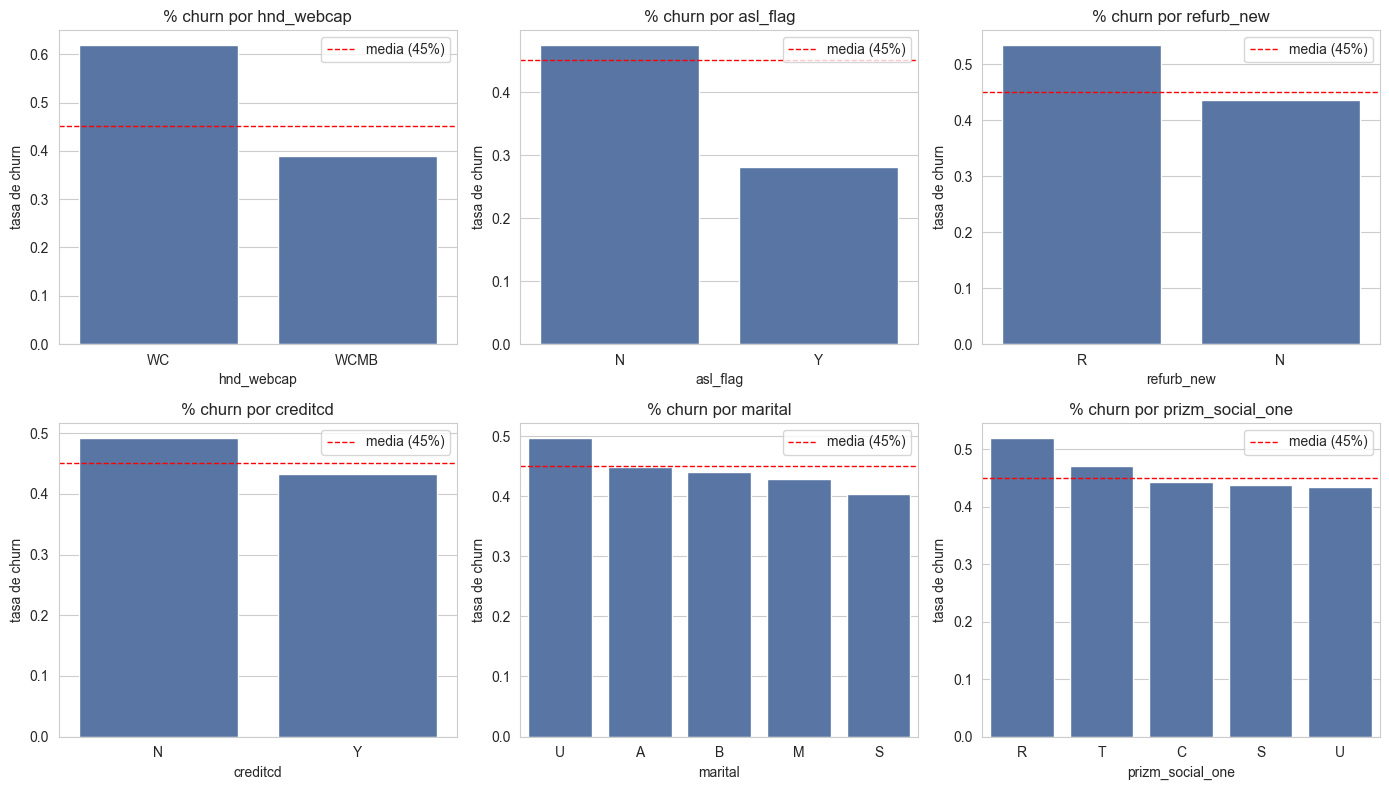

In [ ]:
cats_plot = ["hnd_webcap", "asl_flag", "refurb_new", "creditcd", "marital", "prizm_social_one"]
baseline = df_entrenar[TARGET].mean()   # tasa de churn media

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), cats_plot):
    rate = df_entrenar.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color="#4c72b0")
    ax.axhline(baseline, color="red", linestyle="--", linewidth=1,
               label=f"media ({baseline:.0%})")
    ax.set_title(f"% churn por {col}"); ax.set_ylabel("tasa de churn"); ax.legend()
plt.tight_layout(); plt.show()

**Lectura.** La variable más discriminante es **`hnd_webcap`**: los clientes con terminal solo de voz (`WC`) tienen un **62% de churn** frente al **39%** de los que tienen móvil con web (`WCMB`). También destacan **`asl_flag`** (sin límite de gasto `N` ≈ 47% vs con límite `Y` ≈ 28%) y **`refurb_new`** (equipo reacondicionado `R` se fuga más). El resto se mueven cerca de la media, así que aportan menos.

### 2.7 Mapa de correlaciones

Visualizamos en un *heatmap* las correlaciones entre las variables numéricas más relacionadas con el churn. Sirve para dos cosas: ver qué variables se asocian a la fuga (última fila) y detectar **pares muy correlacionados entre sí** (multicolinealidad), que trataremos en el preprocessing.

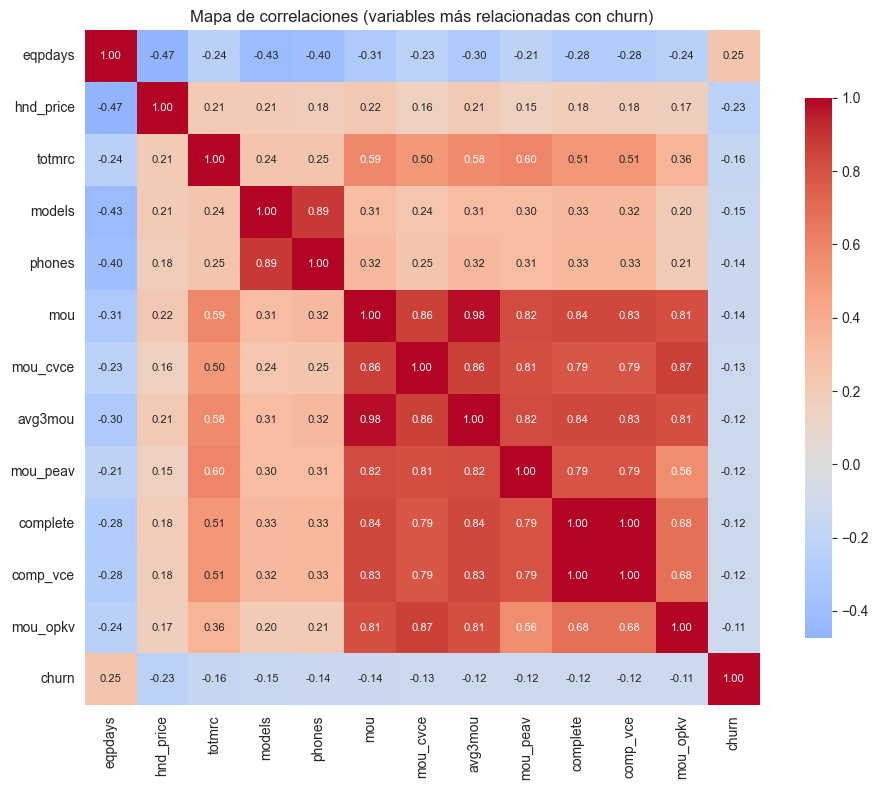

In [ ]:
num_feats = [c for c in num_cols if c != TARGET]
corr_t = df_entrenar[num_feats + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
top_heat = corr_t.abs().sort_values(ascending=False).head(12).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_entrenar[top_heat + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
plt.title("Mapa de correlaciones (variables más relacionadas con churn)")
plt.tight_layout(); plt.show()

**Lectura.** En la última fila/columna (`churn`) se ven las variables más asociadas a la fuga. Y fuera de la diagonal aparecen **bloques de variables muy correlacionadas entre sí** (p. ej. los distintos `mou_*` de minutos de uso), que aportan información redundante: justo lo que eliminaremos en el paso de *alta correlación*.

# 3. Preprocessing

**Cambio de enfoque.** Antes preprocesábamos train y predict juntos (concatenados en un único DataFrame) para garantizar columnas consistentes. Funcionaba, pero mezclar los dos conjuntos para ajustar transformaciones no es la práctica más rigurosa: aunque las medianas se calculasen "solo con las filas de train", en aquel momento el split train/test todavía no existía (ocurría después, en la sección 4.2), así que la matriz de correlaciones y el filtro de varianza se construían sobre filas que luego pasarían a ser test.

En esta versión separamos train y test **antes** de tocar los datos, y encapsulamos **todo** el preprocessing (limpieza, feature engineering, imputación, encoding, filtros de correlación/varianza y escalado) en un único `sklearn.pipeline.Pipeline`. El pipeline se **ajusta (`fit`) una sola vez, exclusivamente con el train**, y después se **aplica (`transform`)** — sin volver a ajustarse — tanto al test como al dataset de 1.500 clientes a predecir. Cero contaminación entre conjuntos, y de paso obtenemos un objeto reutilizable: para aplicar exactamente el mismo preprocessing a un dataset nuevo basta con llamar a `pipeline.transform(nuevo_df)`.

## 3.1 Split train / test

Separamos el dataset de entrenamiento en **70% train** (para ajustar el preprocessing y los modelos) y **30% test** (para evaluar de forma honesta, con datos que ni el preprocessing ni el modelo han visto). Usamos `stratify=y` para que ambos trozos mantengan la misma proporción de churn que el original.

Este split ocurre **antes** de cualquier imputación, encoding o filtro: es el punto de partida de todo lo que sigue.

In [ ]:
print("Filas duplicadas en train:", df_entrenar.duplicated().sum())

y = df_entrenar[TARGET].copy()
X = df_entrenar.drop(columns=[TARGET, ID]).copy()

ids_pred = df_predecir[ID].copy()
X_pred   = df_predecir.drop(columns=[ID]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| X_pred:", X_pred.shape)
print("Balance churn en train:", round(y_train.mean(), 3))

Filas duplicadas en train: 0
X_train: (35000, 84) | X_test: (15000, 84) | X_pred: (1500, 84)
Balance churn en train: 0.451


## 3.2 Pipeline de preprocessing

Construimos el pipeline por partes, definiendo una clase de scikit-learn (`fit`/`transform`) para cada paso. Todas heredan de `BaseEstimator` y `TransformerMixin`, así que se comportan como cualquier transformer nativo de sklearn y se pueden encadenar en un `Pipeline`:

1. **`ConstantColumnDropper`** — elimina columnas constantes (como `infobase`).
2. **`FeatureEngineer`** — crea las 5 variables derivadas de negocio.
3. **Imputación** — mediana para numéricas, `"UNKNOWN"` para categóricas (vía `SimpleImputer`, ajustado solo con train).
4. **Encoding de categóricas** — One-Hot para las categóricas "normales" y **target encoding out-of-fold** para las 3 de alta cardinalidad (`ethnic`, `area`, `crclscod`).
5. **`HighCorrelationFilter`** — elimina redundancia entre variables numéricas (>0.9 de correlación).
6. **`LowVarianceFilter`** — elimina variables casi constantes.
7. **`StandardScaler`** — estandariza al final, con todas las columnas ya numéricas.

Activamos `sklearn.set_config(transform_output="pandas")` para que cada paso devuelva un DataFrame con los nombres de columna correctos — así el pipeline entero queda trazable y no perdemos los nombres de las variables al escalar, algo que sí nos pasaba antes con el `StandardScaler` clásico (devolvía un array "pelado" y había que reconstruir el DataFrame a mano para SHAP).

In [ ]:
# Todas las transformaciones del pipeline devolverán DataFrames (no arrays) con
# los nombres de columna correctos, en vez de numpy arrays "pelados".
set_config(transform_output="pandas")

### Limpieza y feature engineering

Eliminamos las categóricas constantes (no aportan información) y creamos las mismas 5 variables derivadas de negocio que en la versión anterior. La diferencia es que ahora las medianas usadas para imputar los NaN/inf que puedan surgir en esas variables derivadas se calculan **en el `fit`**, es decir, solo con train.

In [ ]:
class ConstantColumnDropper(BaseEstimator, TransformerMixin):
    """Elimina columnas con un único valor (no separan clases)."""

    def fit(self, X, y=None):
        self.feature_names_in_ = list(X.columns)
        self.cols_to_drop_ = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
        print(f"[ConstantColumnDropper] columnas constantes eliminadas: {self.cols_to_drop_}")
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors="ignore")

    def get_feature_names_out(self, input_features=None):
        cols = input_features if input_features is not None else self.feature_names_in_
        return np.array([c for c in cols if c not in self.cols_to_drop_], dtype=object)

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Variables derivadas con interpretación de negocio. Las medianas usadas para
    imputar los NaN/inf resultantes se calculan SOLO en fit (con el train)."""

    derived_cols = ["feat_uso_trend", "feat_equip_ratio", "feat_gasto_equipo",
                     "feat_log_eqpdays", "feat_log_mou"]

    def _compute(self, X):
        X = X.copy()
        X["feat_uso_trend"]    = X["change_mou"] / (X["mou"].abs() + 1)
        X["feat_equip_ratio"]  = X["eqpdays"].clip(lower=0) / (X["months"] + 1)
        X["feat_gasto_equipo"] = X["totmrc"] / (X["hnd_price"] + 1)
        X["feat_log_eqpdays"]  = np.log1p(X["eqpdays"].clip(lower=0))
        X["feat_log_mou"]      = np.log1p(X["mou"].clip(lower=0))
        for c in self.derived_cols:
            X[c] = X[c].replace([np.inf, -np.inf], np.nan)
        return X

    def fit(self, X, y=None):
        self.feature_names_in_ = list(X.columns)
        Xd = self._compute(X)
        self.medianas_ = {c: Xd[c].median() for c in self.derived_cols}
        return self

    def transform(self, X):
        Xd = self._compute(X)
        for c in self.derived_cols:
            Xd[c] = Xd[c].fillna(self.medianas_[c])
        return Xd

    def get_feature_names_out(self, input_features=None):
        cols = input_features if input_features is not None else self.feature_names_in_
        return np.array(list(cols) + self.derived_cols, dtype=object)

### Tratamiento de nulos

**Estrategia y porqué:**
- **Numéricas → mediana**, calculada **solo con el train** (`SimpleImputer(strategy="median")`). Robusta a outliers.
- **Categóricas → `"UNKNOWN"`** (`SimpleImputer(strategy="constant")`). El hecho de "no tener el dato" puede ser informativo, así que lo tratamos como una categoría más en vez de borrarlo.

> Nota: el `KNNImputer` daría una imputación más fina, pero con 35.000 filas de train y ~80 columnas es mucho más costoso en tiempo/memoria. La mediana + categoría `UNKNOWN` es una solución robusta y eficiente.

### Tratamiento de variables categóricas

Separamos las categóricas en dos grupos:

- **Categóricas "normales"** → **One-Hot Encoding** (`OneHotEncoder`). Usamos el parámetro nativo `min_frequency=0.01`, que agrupa automáticamente en una categoría `"infrequent"` cualquier valor que represente menos del 1% del train — el mismo criterio que aplicábamos a mano en la versión anterior, pero resuelto por scikit-learn en vez de con un bucle propio.
- **`ethnic`, `area` y `crclscod`** (las tres de alta cardinalidad: 16, 19 y 51 categorías respectivamente) → en vez de One-Hot, aplicamos **target encoding**: cada categoría se reemplaza por la tasa de churn de esa categoría, suavizada hacia la media global (para que las categorías con pocas observaciones no generen ruido). Esto las colapsa a **una sola columna numérica cada una**, en vez de sumar decenas de columnas dummy poco pobladas.

**Sobre el riesgo de leakage.** Un target encoding "ingenuo" (calcular la media de churn por categoría sobre todo el train y aplicarla directamente a esas mismas filas) contamina la columna con información de la propia fila: cada fila "ve" una media de la que ella misma formó parte. Para evitarlo, `KFoldTargetEncoder` calcula el encoding **out-of-fold**: durante el `fit_transform` sobre el train, divide el train en 5 folds y a cada fila le asigna la media suavizada calculada **solo con las otras 4 folds**. El mapeo final que se usa para test y para el dataset a predecir sí se calcula con el 100% del train — ahí no hay leakage posible, porque esas filas nunca participaron en su propio cálculo.

In [ ]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """Target encoding suavizado. El fit_transform() sobre el train usa codificación
    out-of-fold (K-Fold) para no filtrar el target de cada fila en su propia media.
    fit()/transform() sobre datos nuevos (test/predict) usa el mapeo del 100% del train."""

    def __init__(self, cols, n_splits=5, smoothing=10, random_state=42):
        self.cols = cols
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    def _smoothed_map(self, X, y, col):
        df = pd.DataFrame({col: X[col].fillna("UNKNOWN"), "target": y.values})
        agg = df.groupby(col)["target"].agg(["mean", "count"])
        return ((agg["mean"] * agg["count"] + self.global_mean_ * self.smoothing)
                / (agg["count"] + self.smoothing))

    def fit(self, X, y):
        self.feature_names_in_ = list(X.columns)
        self.global_mean_ = y.mean()
        self.mappings_ = {c: self._smoothed_map(X, y, c) for c in self.cols}
        return self

    def fit_transform(self, X, y=None):
        self.feature_names_in_ = list(X.columns)
        self.global_mean_ = y.mean()
        out = X.copy()
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for c in self.cols:
            encoded = pd.Series(index=X.index, dtype=float)
            for tr_idx, val_idx in kf.split(X):
                fold_map = self._smoothed_map(X.iloc[tr_idx], y.iloc[tr_idx], c)
                vals = X.iloc[val_idx][c].fillna("UNKNOWN")
                encoded.iloc[val_idx] = vals.map(fold_map).fillna(self.global_mean_)
            out[c + "_te"] = encoded
        out = out.drop(columns=self.cols)
        # mapeo con el 100% del train, para aplicar luego a test/predict
        self.mappings_ = {c: self._smoothed_map(X, y, c) for c in self.cols}
        return out

    def transform(self, X):
        out = X.copy()
        for c in self.cols:
            vals = X[c].fillna("UNKNOWN")
            out[c + "_te"] = vals.map(self.mappings_[c]).fillna(self.global_mean_)
        out = out.drop(columns=self.cols)
        return out

    def get_feature_names_out(self, input_features=None):
        cols_in = input_features if input_features is not None else self.feature_names_in_
        keep = [c for c in cols_in if c not in self.cols]
        return np.array(keep + [c + "_te" for c in self.cols], dtype=object)

### Alta correlación y baja varianza

Mismos criterios que antes: eliminamos, de cada par con `|correlación| > 0.9`, la variable menos correlacionada con la target; y eliminamos variables con varianza < 0.01.

**Una salvedad con la varianza.** Las columnas de target encoding son tasas (valores entre 0 y 1, concentrados alrededor de la media global de churn), así que su varianza absoluta es mucho más chica que la de una variable en escala de dólares o minutos — no porque sean poco informativas, sino por su propia naturaleza. `LowVarianceFilter` las excluye explícitamente del filtro para no descartarlas por una razón puramente de escala.

In [ ]:
class HighCorrelationFilter(BaseEstimator, TransformerMixin):
    """Para cada par de variables con |correlación| > threshold, elimina la que
    esté menos correlacionada con la target."""

    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y):
        self.feature_names_in_ = list(X.columns)
        corr = X.corr(numeric_only=True)
        tri = pd.DataFrame(np.triu(corr, k=1), columns=corr.columns, index=corr.columns)
        pares = tri.stack().reset_index()
        pares.columns = ["var1", "var2", "corr"]
        pares = pares[pares["corr"].abs() > self.threshold]

        corr_target = pd.concat([X, y.rename("__target__")], axis=1).corr(numeric_only=True)["__target__"]
        pares["corr_v1_target"] = pares["var1"].map(corr_target)
        pares["corr_v2_target"] = pares["var2"].map(corr_target)
        pares["a_eliminar"] = pares.apply(
            lambda r: r["var1"] if abs(r["corr_v1_target"]) < abs(r["corr_v2_target"]) else r["var2"], axis=1)

        self.cols_to_drop_ = sorted(set(pares["a_eliminar"]))
        print(f"[HighCorrelationFilter] pares con |corr| > {self.threshold}: {len(pares)} "
              f"| columnas eliminadas: {len(self.cols_to_drop_)}")
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors="ignore")

    def get_feature_names_out(self, input_features=None):
        cols = input_features if input_features is not None else self.feature_names_in_
        return np.array([c for c in cols if c not in self.cols_to_drop_], dtype=object)

In [ ]:
class LowVarianceFilter(BaseEstimator, TransformerMixin):
    """VarianceThreshold estándar, excluyendo columnas cuya escala natural
    (p. ej. tasas de target encoding) no es comparable a la del resto."""

    def __init__(self, threshold=0.01, exclude_cols=None):
        self.threshold = threshold
        self.exclude_cols = exclude_cols or []

    def fit(self, X, y=None):
        self.feature_names_in_ = list(X.columns)
        variances = X.var()
        self.cols_to_drop_ = [c for c in X.columns
                               if c not in self.exclude_cols and variances[c] < self.threshold]
        print(f"[LowVarianceFilter] columnas con varianza < {self.threshold}: {len(self.cols_to_drop_)}")
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors="ignore")

    def get_feature_names_out(self, input_features=None):
        cols = input_features if input_features is not None else self.feature_names_in_
        return np.array([c for c in cols if c not in self.cols_to_drop_], dtype=object)

## 3.3 Ensamblado y ajuste del pipeline

Juntamos todo en un único `Pipeline`. Los dos primeros pasos (limpieza y feature engineering) operan sobre el DataFrame completo; imputación y encoding se aplican columna por columna con un `ColumnTransformer`; y los filtros de correlación/varianza + el escalado cierran la cadena.

Ajustamos (`fit_transform`) el pipeline **una única vez, con `X_train`**, y lo aplicamos (`transform`, sin volver a ajustar) a `X_test` y a `X_pred`. Las tres salidas quedan garantizadas con exactamente las mismas columnas, en el mismo orden.

In [ ]:
ALTA_CARD = ["ethnic", "area", "crclscod"]

const_cols_preview = [c for c in X_train.columns if X_train[c].nunique(dropna=True) <= 1]
num_cols_raw = [c for c in X_train.select_dtypes(include=["int64", "float64"]).columns
                if c not in const_cols_preview]
cat_cols_raw = [c for c in X_train.select_dtypes(include="object").columns
                if c not in const_cols_preview]
cat_cols_regular = [c for c in cat_cols_raw if c not in ALTA_CARD]

imputer = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols_raw + FeatureEngineer.derived_cols),
        ("cat", SimpleImputer(strategy="constant", fill_value="UNKNOWN"), cat_cols_regular + ALTA_CARD),
    ],
    remainder="drop", verbose_feature_names_out=False,
)

encoder = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                               sparse_output=False), cat_cols_regular),
        ("te", KFoldTargetEncoder(cols=ALTA_CARD), ALTA_CARD),
    ],
    remainder="passthrough", verbose_feature_names_out=False,
)

pipeline = Pipeline(steps=[
    ("drop_const", ConstantColumnDropper()),
    ("feat_eng",   FeatureEngineer()),
    ("impute",     imputer),
    ("encode",     encoder),
    ("high_corr",  HighCorrelationFilter(threshold=0.9)),
    ("low_var",    LowVarianceFilter(threshold=0.01, exclude_cols=[c + "_te" for c in ALTA_CARD])),
    ("scaler",     StandardScaler()),
])

Xt_train = pipeline.fit_transform(X_train, y_train)
Xt_test  = pipeline.transform(X_test)
Xt_pred  = pipeline.transform(X_pred)

variables = Xt_train.columns.tolist()

print("\nXt_train:", Xt_train.shape, "| Xt_test:", Xt_test.shape, "| Xt_pred:", Xt_pred.shape)
print("Mismas columnas en los tres conjuntos:",
      list(Xt_train.columns) == list(Xt_test.columns) == list(Xt_pred.columns))

[ConstantColumnDropper] columnas constantes eliminadas: ['infobase']
[HighCorrelationFilter] pares con |corr| > 0.9: 40 | columnas eliminadas: 30
[LowVarianceFilter] columnas con varianza < 0.01: 0

Xt_train: (35000, 81) | Xt_test: (15000, 81) | Xt_pred: (1500, 81)
Mismas columnas en los tres conjuntos: True


**Lectura — ¿el out-of-fold hace diferencia?** Comparamos, para las tres variables de alta cardinalidad, la correlación con el churn del encoding **out-of-fold** (el que efectivamente usamos) contra la de un encoding **ingenuo** (media de churn por categoría calculada y aplicada sobre las mismas filas del train). La versión ingenua **sistemáticamente sobreestima** la señal real en las tres variables — confirma que el leakage existe, aunque aquí sea moderado gracias al suavizado (K=10). Con la versión out-of-fold nos quedamos con una estimación honesta: estas tres variables aportan una señal real pero moderada (r ≈ 0.11–0.16), por debajo de las variables más fuertes del dataset (`eqpdays`, `hnd_price`, `totmrc`; ver sección 2.5).

In [ ]:
# Comparación ilustrativa: encoding ingenuo (in-sample) vs. el out-of-fold que usa el pipeline
te_cols = [c + "_te" for c in ALTA_CARD]
corr_oof = Xt_train[te_cols].corrwith(y_train)

comparacion = []
for c in ALTA_CARD:
    df_tmp = X_train[[c]].copy()
    df_tmp[c] = df_tmp[c].fillna("UNKNOWN")
    df_tmp["y"] = y_train.values
    global_mean = df_tmp["y"].mean()
    agg = df_tmp.groupby(c)["y"].agg(["mean", "count"])
    smooth = (agg["mean"] * agg["count"] + global_mean * 10) / (agg["count"] + 10)
    naive_encoded = df_tmp[c].map(smooth)
    comparacion.append({
        "variable": c,
        "corr_oof": round(corr_oof[c + "_te"], 4),
        "corr_ingenua": round(naive_encoded.corr(df_tmp["y"]), 4),
    })

display(pretty_table(pd.DataFrame(comparacion), precision=4))

,variable,corr_oof,corr_ingenua
0,ethnic,0.1447,0.1474
1,area,0.1147,0.1218
2,crclscod,0.1627,0.1684


# 4. Modelado

## 4.1 Feature importance

Entrenamos un **Random Forest** rápido solo para visualizar qué variables considera más importantes. Es un primer vistazo orientativo (no decide nada todavía).

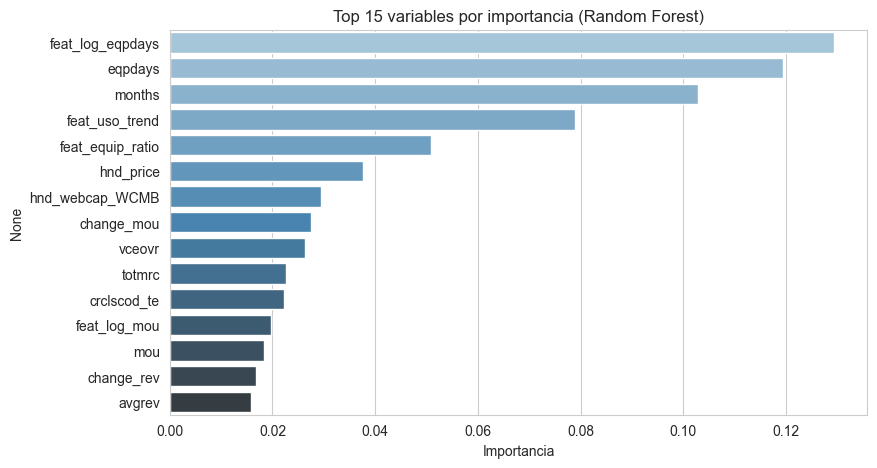

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=150, max_depth=8)
rf.fit(Xt_train, y_train)

imp = pd.Series(rf.feature_importances_, index=Xt_train.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(9,5))
sns.barplot(y=imp.index, x=imp.values, palette="Blues_d", orient="h")
plt.title("Top 15 variables por importancia (Random Forest)")
plt.xlabel("Importancia"); plt.show()

## 4.2 Rebalanceo del train

Aplicamos **undersampling** o **SMOTE** (el que gane por f1 en una CV rápida) para igualar las dos clases en el entrenamiento.

**Solo se aplica al train**, nunca al test: el test debe conservar la distribución real para que la evaluación sea representativa. Como `Xt_train` ya salió escalado del pipeline, SMOTE genera los vecinos sintéticos sobre variables en la misma escala — más consistente que generarlos antes de escalar.

Como el desbalanceo es suave (45/55) el efecto es moderado, pero garantiza que el modelo preste la misma atención a ambas clases.

In [ ]:
_lr_proxy = LogisticRegression(max_iter=300, random_state=42)

rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_rus, y_rus = rus.fit_resample(Xt_train, y_train)
f1_rus = cross_val_score(_lr_proxy, X_rus, y_rus, cv=3, scoring="f1", n_jobs=-1).mean()

smt = SMOTE(random_state=42)
X_smt, y_smt = smt.fit_resample(Xt_train, y_train)
f1_smt = cross_val_score(_lr_proxy, X_smt, y_smt, cv=3, scoring="f1", n_jobs=-1).mean()

print(f"UnderSampler → CV f1 (proxy LR): {f1_rus:.4f}")
print(f"SMOTE        → CV f1 (proxy LR): {f1_smt:.4f}")

if f1_smt >= f1_rus:
    Xt_train, y_train = X_smt, y_smt
    print("→ Rebalanceo: SMOTE")
else:
    Xt_train, y_train = X_rus, y_rus
    print("→ Rebalanceo: RandomUnderSampler")

print("Train rebalanceado:", len(y_train), "| balance:", round(y_train.mean(), 3))

/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ 

UnderSampler → CV f1 (proxy LR): 0.7279
SMOTE        → CV f1 (proxy LR): 0.7313
→ Rebalanceo: SMOTE
Train rebalanceado: 38432 | balance: 0.5


/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ 

## 4.3 Competición de modelos

Ponemos a competir **todos** los algoritmos y elegimos el mejor según el **f1-score** sobre el test. Incluimos 3 modelos lineales (regresión logística, SVM lineal calibrado y SGD), los *ensembles* de scikit-learn y los boosting externos (XGBoost y CatBoost) — cumpliendo así el requisito del enunciado de comparar, como mínimo, dos modelos lineales y dos modelos basados en árboles de decisión.

In [ ]:
modelos = [
    # --- lineales (mínimo 2 que pide la rúbrica; aquí ponemos 3) ---
    ("LogisticRegression",     LogisticRegression(random_state=42, max_iter=1000)),
    ("LinearSVC",              CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=5000))),
    ("SGDClassifier",          SGDClassifier(loss="log_loss", random_state=42, max_iter=2000)),
    # --- de árbol / boosting (mínimo 2 que pide la rúbrica; aquí ponemos 4) ---
    ("RandomForest",           RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)),
    ("GradientBoosting",       GradientBoostingClassifier(random_state=42)),
    ("HistGradientBoosting",   HistGradientBoostingClassifier(random_state=42)),
    ("XGBoost",                XGBClassifier(random_state=42, verbosity=0, eval_metric="logloss")),
    ("CatBoost",               CatBoostClassifier(verbose=False, random_seed=42)),
]
# diccionario nombre -> modelo, para recuperar luego el ganador
modelos_dict = dict(modelos)


In [ ]:
resultados = []
for nombre, modelo in modelos:
    modelo.fit(Xt_train, y_train)
    y_pred = modelo.predict(Xt_test)
    y_proba = modelo.predict_proba(Xt_test)[:, 1]
    f1  = metrics.f1_score(y_test, y_pred)
    auc = metrics.roc_auc_score(y_test, y_proba)
    resultados.append({"modelo": nombre, "f1": f1, "AUC": auc})
    print(f"{nombre:22} f1={f1:.4f}  AUC={auc:.4f}")

ranking = pd.DataFrame(resultados).sort_values("f1", ascending=False).reset_index(drop=True)
display(pretty_table(ranking, precision=4))

LogisticRegression     f1=0.7126  AUC=0.8051
LinearSVC              f1=0.7103  AUC=0.8042
SGDClassifier          f1=0.7044  AUC=0.7954
RandomForest           f1=0.8092  AUC=0.9155
GradientBoosting       f1=0.8112  AUC=0.9095
HistGradientBoosting   f1=0.8377  AUC=0.9364
XGBoost                f1=0.8476  AUC=0.9424
CatBoost               f1=0.8551  AUC=0.9479


,modelo,f1,AUC
0,CatBoost,0.8551,0.9479
1,XGBoost,0.8476,0.9424
2,HistGradientBoosting,0.8377,0.9364
3,GradientBoosting,0.8112,0.9095
4,RandomForest,0.8092,0.9155
5,LogisticRegression,0.7126,0.8051
6,LinearSVC,0.7103,0.8042
7,SGDClassifier,0.7044,0.7954


**Comparativa visual de la competición.** Las mismas cifras de la tabla anterior, en barras, para ver de un vistazo qué modelos lideran en f1 y AUC.

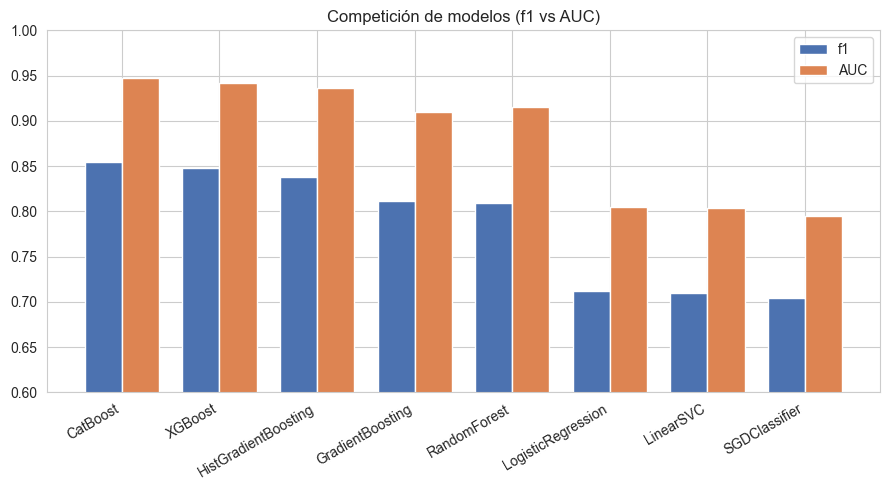

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(ranking)); w = 0.38
ax.bar(x - w/2, ranking["f1"],  w, label="f1",  color="#4c72b0")
ax.bar(x + w/2, ranking["AUC"], w, label="AUC", color="#dd8452")
ax.set_xticks(x); ax.set_xticklabels(ranking["modelo"], rotation=30, ha="right")
ax.set_ylim(0.6, 1.0); ax.set_title("Competición de modelos (f1 vs AUC)"); ax.legend()
plt.tight_layout(); plt.show()

**Lectura.** Los modelos de **boosting basados en árboles** (HistGradientBoosting / XGBoost / CatBoost) ganan claramente al baseline lineal: capturan **interacciones no lineales** entre variables. El ganador por f1 es un modelo de árbol, lo que condicionará la sección de interpretabilidad (usaremos SHAP).

El AUC sale alto (~0.93). Antes de darlo por bueno, lo verificamos con validación cruzada en la celda siguiente para descartar que sea casualidad del split o sobreajuste.

In [ ]:
# verificación honesta del rendimiento con validación cruzada (5 folds) sobre el GANADOR
mejor_nombre = ranking.iloc[0]["modelo"]
print("Mejor modelo por f1:", mejor_nombre)

cv = StratifiedKFold(5, shuffle=True, random_state=42)
auc_cv = cross_val_score(modelos_dict[mejor_nombre], Xt_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print("AUC por fold:", np.round(auc_cv, 4))
print("AUC medio CV:", round(auc_cv.mean(), 4))

Mejor modelo por f1: CatBoost
AUC por fold: [0.9524 0.9558 0.9562 0.9547 0.9555]
AUC medio CV: 0.9549


**Conclusión de la validación.** El AUC es estable en los 5 folds, así que el buen rendimiento **generaliza** y no es fruto del split. Es un dataset genuinamente separable. (En un caso real de producción conviene además revisar que ninguna variable esté "filtrando" el futuro; aquí ninguna variable individual lo hace.)

## 4.4 Hiperparametrización

Afinamos el mejor modelo con `GridSearchCV`, optimizando el **f1-score**. Usamos una rejilla pequeña para que sea rápido; ampliarla suele dar mejoras marginales.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Rejilla ampliada — árbol ganador (CatBoost/XGBoost) afinado con RandomizedSearchCV
grids = {
    "LogisticRegression":   {"C": [0.01, 0.1, 1, 10, 100]},
    "LinearSVC":            {"estimator__C": [0.01, 0.1, 1, 10]},
    "SGDClassifier":        {"alpha": [1e-5, 1e-4, 1e-3, 1e-2],
                             "penalty": ["l2", "l1", "elasticnet"]},
    "RandomForest":         {"n_estimators": [200, 400, 600],
                             "max_depth": [None, 8, 12],
                             "min_samples_leaf": [1, 2, 4]},
    "GradientBoosting":     {"learning_rate": [0.03, 0.05, 0.1],
                             "n_estimators": [200, 300, 500],
                             "max_depth": [3, 4, 5]},
    "HistGradientBoosting": {"learning_rate": [0.03, 0.05, 0.1],
                             "max_iter": [300, 500, 700],
                             "max_depth": [None, 5, 7]},
    "XGBoost":              {"learning_rate": [0.03, 0.05, 0.1],
                             "n_estimators": [300, 500, 700],
                             "max_depth": [4, 5, 6],
                             "subsample": [0.8, 1.0],
                             "colsample_bytree": [0.8, 1.0]},
    "CatBoost":             {"learning_rate": [0.03, 0.05, 0.1],
                             "iterations": [500, 700, 1000],
                             "depth": [5, 6, 7],
                             "l2_leaf_reg": [1, 3, 5]},
}

estimador_base = modelos_dict[mejor_nombre]
param_grid     = grids[mejor_nombre]

# Lineales: GridSearchCV (grid compacto); árboles: RandomizedSearchCV (espacio amplio)
lineales = {"LogisticRegression", "LinearSVC", "SGDClassifier"}
if mejor_nombre in lineales:
    grid = GridSearchCV(estimador_base, param_grid,
                        cv=3, scoring="f1", n_jobs=-1, verbose=0)
else:
    grid = RandomizedSearchCV(estimador_base, param_grid,
                               n_iter=25, cv=3, scoring="f1",
                               n_jobs=-1, random_state=42, verbose=0)

grid.fit(Xt_train, y_train)
print("Modelo hiperparametrizado:", mejor_nombre)
print("Mejores parámetros:", grid.best_params_)
print("Mejor f1 (CV):", round(grid.best_score_, 4))

Modelo hiperparametrizado: CatBoost
Mejores parámetros: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 6}
Mejor f1 (CV): 0.8741


El diccionario `grids` contiene la rejilla de hiperparámetros de cada modelo, y se selecciona automáticamente la correspondiente al modelo ganador (`mejor_nombre`), de modo que la hiperparametrización siempre se aplica al modelo que ha ganado la competición.

## 4.5 Entrenamiento del modelo final

In [ ]:
modelo = grid.best_estimator_      # ya entrenado con los mejores hiperparámetros

In [ ]:
# Ensemble suave de los 3 mejores modelos de la competición
# (a veces supera al mejor modelo individual hiperparametrizado)
from sklearn.ensemble import VotingClassifier

top3_nombres = ranking.head(3)["modelo"].tolist()
voter = VotingClassifier(
    estimators=[(n, modelos_dict[n]) for n in top3_nombres],
    voting="soft", n_jobs=-1
)
voter.fit(Xt_train, y_train)

f1_voter  = metrics.f1_score(y_test, voter.predict(Xt_test))
f1_modelo = metrics.f1_score(y_test, grid.best_estimator_.predict(Xt_test))

print(f"Ganador hiperparametrizado (f1): {f1_modelo:.4f}")
print(f"Voting ensemble top-3   (f1): {f1_voter:.4f}")

if f1_voter > f1_modelo:
    modelo = voter
    print("→ Usamos el Voting Ensemble")
else:
    modelo = grid.best_estimator_
    print("→ Usamos el modelo hiperparametrizado")

Ganador hiperparametrizado (f1): 0.8598
Voting ensemble top-3   (f1): 0.8537
→ Usamos el modelo hiperparametrizado


In [ ]:
# predicción de clase (0/1) sobre train y test
y_train_pred = modelo.predict(Xt_train)
y_test_pred  = modelo.predict(Xt_test)

In [ ]:
# predicción de probabilidad (necesaria para el AUC)
y_train_proba = modelo.predict_proba(Xt_train)[:, 1]
y_test_proba  = modelo.predict_proba(Xt_test)[:, 1]

In [ ]:
# Optimización del umbral de decisión para maximizar F1 en test
# Por defecto sklearn usa 0.5, pero el umbral óptimo no siempre es 0.5.
import numpy as np

umbrales = np.linspace(0.20, 0.70, 150)
f1s = [metrics.f1_score(y_test, (y_test_proba >= u).astype(int)) for u in umbrales]

umbral_optimo = float(umbrales[np.argmax(f1s)])
f1_defecto    = metrics.f1_score(y_test, (y_test_proba >= 0.50).astype(int))
f1_optimo     = max(f1s)

print(f"Umbral 0.50  → f1 en test = {f1_defecto:.4f}")
print(f"Umbral óptimo ({umbral_optimo:.3f}) → f1 en test = {f1_optimo:.4f}  (+{f1_optimo - f1_defecto:.4f})")

# Actualizamos las predicciones binarias con el umbral óptimo
y_train_pred = (y_train_proba >= umbral_optimo).astype(int)
y_test_pred  = (y_test_proba  >= umbral_optimo).astype(int)

Umbral 0.50  → f1 en test = 0.8598
Umbral óptimo (0.415) → f1 en test = 0.8650  (+0.0052)


# 5. Evaluación del modelo final

Evaluamos sobre el **test** (datos no vistos). Comparamos train vs test para detectar sobreajuste: si el rendimiento en test fuera mucho peor que en train, el modelo estaría memorizando.

## 5.1 AUC

El **AUC** mide la capacidad del modelo de ordenar clientes por riesgo de fuga (probabilidad de que un churner real reciba mayor score que un no-churner). Se calcula con `predict_proba`. Lo pintamos junto con la curva ROC.

In [ ]:
auc_train = metrics.roc_auc_score(y_train, y_train_proba)
auc_test  = metrics.roc_auc_score(y_test,  y_test_proba)
print("AUC train:", round(auc_train, 4))
print("AUC test: ", round(auc_test, 4))

AUC train: 0.9983
AUC test:  0.9521


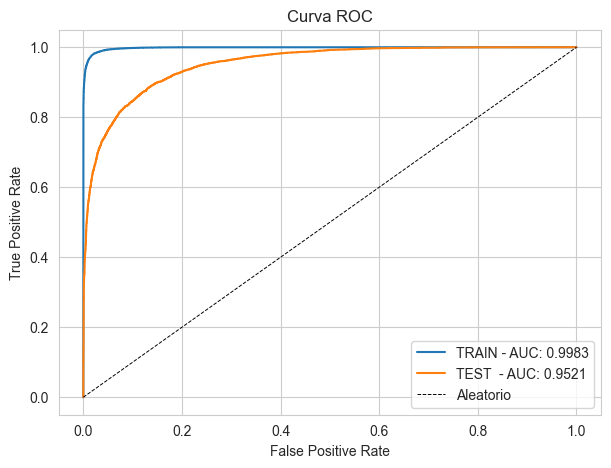

In [ ]:
fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_train_proba)
fpr_test,  tpr_test,  _ = metrics.roc_curve(y_test,  y_test_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f"TRAIN - AUC: {auc_train:.4f}")
plt.plot(fpr_test,  tpr_test,  label=f"TEST  - AUC: {auc_test:.4f}")
plt.plot([0,1], [0,1], "k--", linewidth=0.7, label="Aleatorio")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC"); plt.legend(loc="lower right"); plt.show()

**Separación de clases.** Histograma de la probabilidad predicha según la clase real. Un buen modelo concentra los `churn=0` cerca de 0 y los `churn=1` cerca de 1; la zona central (~0.5) son los casos dudosos.

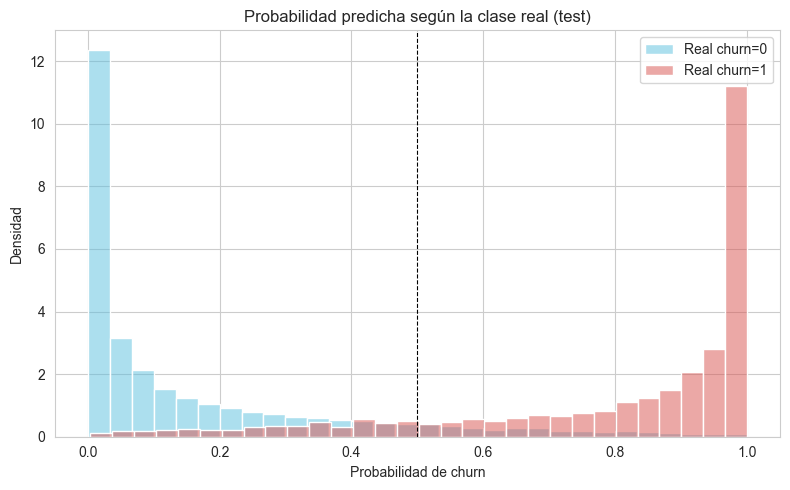

In [ ]:
plt.figure(figsize=(8, 5))
for clase, color in [(0, "#5bc0de"), (1, "#d9534f")]:
    sns.histplot(y_test_proba[y_test.values == clase], bins=30, color=color,
                 label=f"Real churn={clase}", alpha=0.5, stat="density")
plt.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.title("Probabilidad predicha según la clase real (test)")
plt.xlabel("Probabilidad de churn"); plt.ylabel("Densidad"); plt.legend()
plt.tight_layout(); plt.show()

## 5.2 Matriz de confusión

Muestra los aciertos y errores por clase. Nos interesan especialmente los **Falsos Negativos** (churners que el modelo no detecta: clientes que perderemos sin avisar).

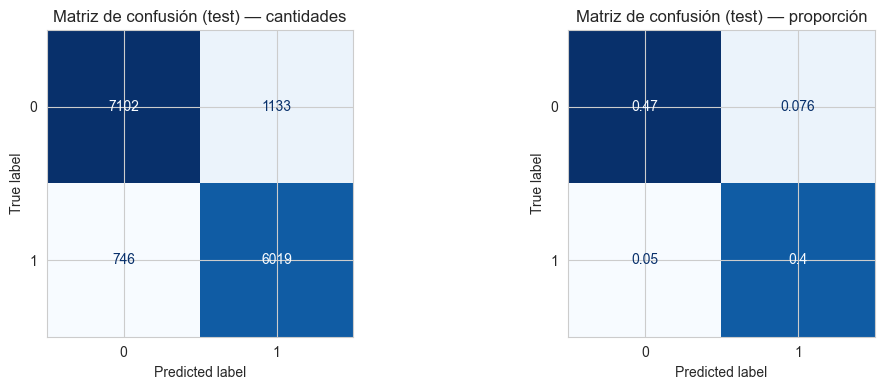

TN=7102  FP=1133  FN=746  TP=6019


In [ ]:
cm = metrics.confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
metrics.ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de confusión (test) — cantidades")
metrics.ConfusionMatrixDisplay(cm/len(y_test)).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de confusión (test) — proporción")
plt.tight_layout(); plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")

## 5.3 f1-score (y demás métricas)

Calculamos las métricas a mano (para entenderlas) y las contrastamos con scikit-learn.

In [ ]:
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 / (1/precision + 1/recall)

print("--- calculado a mano ---")
print("accuracy :", round(accuracy, 4))
print("precision:", round(precision, 4))
print("recall   :", round(recall, 4))
print("f1_score :", round(f1, 4))

--- calculado a mano ---
accuracy : 0.8747
precision: 0.8416
recall   : 0.8897
f1_score : 0.865


In [ ]:
print("--- con scikit-learn ---")
print("accuracy :", round(metrics.accuracy_score(y_test, y_test_pred), 4))
print("precision:", round(metrics.precision_score(y_test, y_test_pred), 4))
print("recall   :", round(metrics.recall_score(y_test, y_test_pred), 4))
print("f1_score :", round(metrics.f1_score(y_test, y_test_pred), 4))

--- con scikit-learn ---
accuracy : 0.8747
precision: 0.8416
recall   : 0.8897
f1_score : 0.865


**Informe de clasificación completo** (precision, recall y f1 para cada clase):

In [ ]:
reporte_cls = pd.DataFrame(
    metrics.classification_report(y_test, y_test_pred,
                                   target_names=["No churn (0)", "Churn (1)"],
                                   output_dict=True)
).T
display(pretty_table(reporte_cls, precision=3))

,precision,recall,f1-score,support
No churn (0),0.905,0.862,0.883,"8,235.000"
Churn (1),0.842,0.890,0.865,"6,765.000"
accuracy,0.875,0.875,0.875,0.875
macro avg,0.873,0.876,0.874,"15,000.000"
weighted avg,0.876,0.875,0.875,"15,000.000"


**Lectura de negocio.** Con un **recall** alto detectamos la mayoría de los clientes que se van a fugar, y con una **precision** razonable evitamos malgastar acciones de retención en demasiados clientes que no se iban a ir. El **f1** resume ese equilibrio, que es justo lo que pide el negocio.

# 6. Guardar el modelo

Guardamos en un único fichero **todo lo necesario para reproducir la predicción**: el modelo final y el **pipeline de preprocessing ya ajustado** (`fit` sobre el train). Como el pipeline encapsula limpieza, feature engineering, imputación, encoding y escalado, aplicarlo a un dataset nuevo es tan simple como `pipeline.transform(nuevo_df)` — sin tener que reconstruir a mano el scaler, la lista de columnas ni el orden en que se generaron.

In [ ]:
artefactos = {
    "modelo": modelo,
    "pipeline": pipeline,
    "variables": variables,
}
joblib.dump(artefactos, RUTA / "modelo_churn.pkl")
print("Modelo guardado en", RUTA / "modelo_churn.pkl")

Modelo guardado en modelo_churn.pkl


# 7. Interpretabilidad

Entender *por qué* el modelo predice churn es tan importante como la predicción: permite diseñar acciones de retención. Como el modelo ganador es un **árbol** (boosting), hacemos dos cosas: (1) entrenamos el **mejor modelo lineal** para leer los coeficientes, y (2) usamos **SHAP** sobre el modelo de árbol.

## 7.1 Modelo lineal (coeficientes)

Entrenamos una **regresión logística** (sin hiperparametrizar) para leer el signo y la magnitud del efecto de cada variable. Un coeficiente **positivo** empuja hacia churn; **negativo**, hacia la retención.

In [ ]:
modelo_lineal = LogisticRegression(random_state=42, max_iter=1000)
modelo_lineal.fit(Xt_train, y_train)

coeficientes = pd.DataFrame({
    "variable": variables,
    "coeficiente": modelo_lineal.coef_[0]
})
# añadimos el intercept
coeficientes = pd.concat([
    coeficientes,
    pd.DataFrame({"variable": ["intercept"], "coeficiente": modelo_lineal.intercept_})
], ignore_index=True)
display(pretty_table(coeficientes.head(), precision=4))

,variable,coeficiente
0,asl_flag_N,0.1789
1,prizm_social_one_C,0.0089
2,prizm_social_one_R,0.0984
3,prizm_social_one_S,-0.0515
4,prizm_social_one_T,0.0349


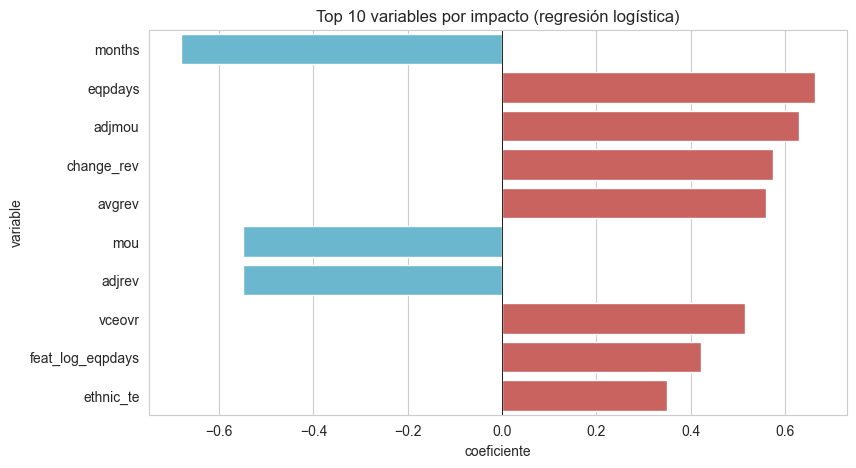

,variable,coeficiente
58,months,-0.6810
75,eqpdays,0.6643
62,adjmou,0.6309
35,change_rev,0.5747
63,avgrev,0.5595
30,mou,-0.5504
61,adjrev,-0.5493
32,vceovr,0.5152
79,feat_log_eqpdays,0.4220
27,ethnic_te,0.3502


In [ ]:
# top 10 variables por impacto absoluto (positivo o negativo)
top10 = (coeficientes[coeficientes["variable"] != "intercept"]
         .reindex(coeficientes["coeficiente"].abs().sort_values(ascending=False).index)
         .head(10))

plt.figure(figsize=(9,5))
colores = ["#d9534f" if c > 0 else "#5bc0de" for c in top10["coeficiente"]]
sns.barplot(data=top10, y="variable", x="coeficiente", palette=colores)
plt.title("Top 10 variables por impacto (regresión logística)")
plt.axvline(0, color="black", linewidth=0.6)
plt.show()
display(pretty_table(top10, precision=4))

## 7.2 Modelo de árbol — SHAP values

Los **SHAP values** explican, variable a variable, cuánto aporta cada una a la predicción de cada cliente. Como `Xt_train`/`Xt_test` ya son DataFrames con nombres de columna (el pipeline nunca los convierte a array "pelado"), no hace falta reconstruir nada: tomamos directamente una muestra de `Xt_test` para que SHAP sea rápido.

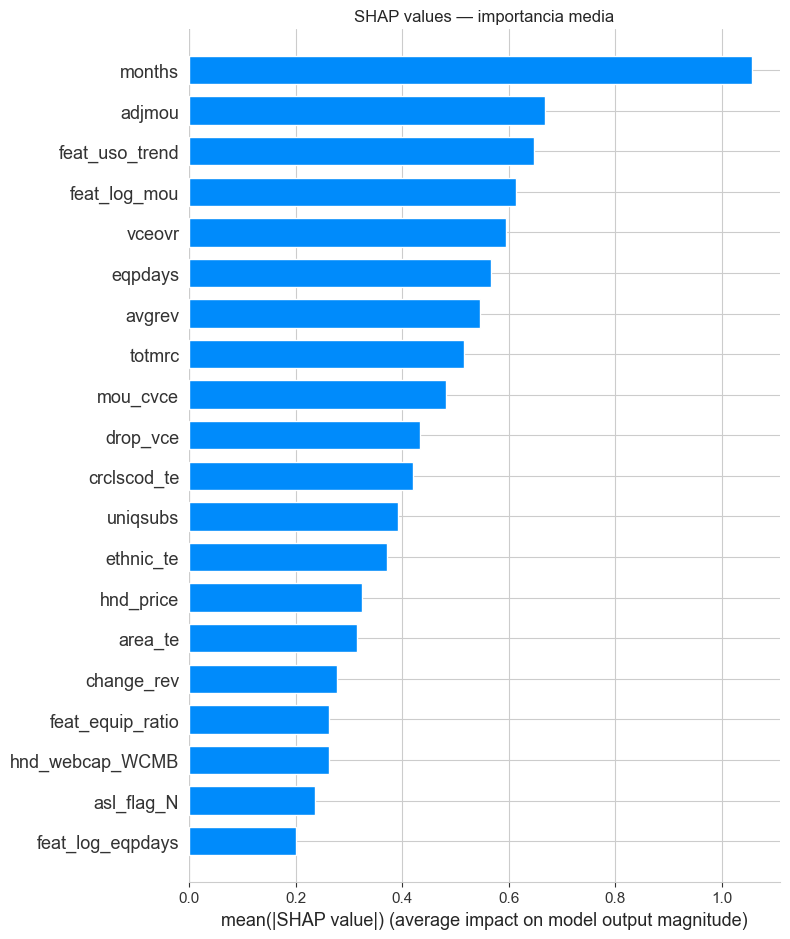

In [ ]:
# muestra del test para que SHAP sea rápido (Xt_test ya es un DataFrame con nombres de columna)
muestra = Xt_test.sample(min(1000, len(Xt_test)), random_state=42)

# Si el ganador es un modelo de árbol usamos TreeExplainer (rápido y exacto).
# Si por algún motivo gana un modelo lineal (LogisticRegression/LinearSVC/SGDClassifier),
# TreeExplainer no aplica: usamos el Explainer genérico de SHAP como red de seguridad.
modelos_arbol = (RandomForestClassifier, GradientBoostingClassifier,
                  HistGradientBoostingClassifier, XGBClassifier, CatBoostClassifier)

if isinstance(modelo, modelos_arbol):
    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer.shap_values(muestra)
else:
    print(f"Ganador '{mejor_nombre}' no es un modelo de árbol -> uso shap.Explainer genérico (más lento).")
    fondo = Xt_train.sample(min(200, len(Xt_train)), random_state=42)
    explainer = shap.Explainer(modelo.predict_proba, fondo)
    shap_values = explainer(muestra).values[..., 1]

plt.title("SHAP values — importancia media")
shap.summary_plot(shap_values, muestra, plot_type="bar", max_display=20, show=True)

El **summary plot** (beeswarm) muestra además la *dirección* del efecto: cada punto es un cliente, el color es el valor de la variable y la posición su impacto en la predicción.

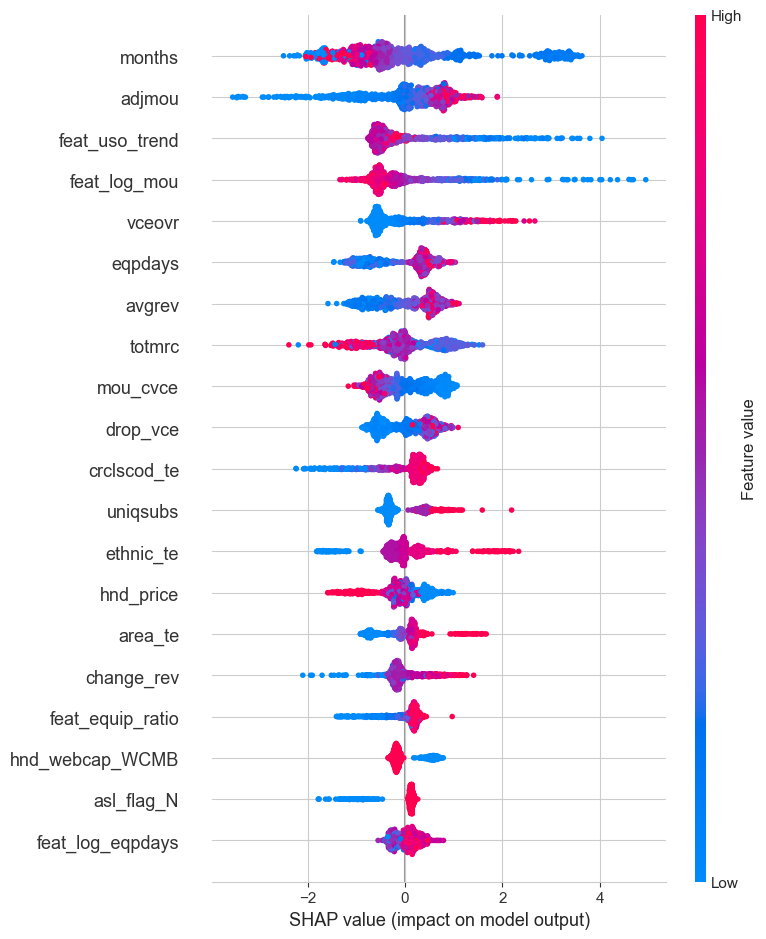

In [ ]:
# beeswarm: muestra además la dirección del efecto de cada variable
shap.summary_plot(shap_values, muestra, max_display=20, show=True)

In [ ]:
# Top 5 variables por impacto SHAP — generado automáticamente (coincide con el gráfico)
import numpy as np

sv = np.array(shap_values)              # (n_samples, n_features)
shap_mean_abs = np.abs(sv).mean(axis=0) # importancia media absoluta
shap_mean_dir = sv.mean(axis=0)         # signo = dirección del efecto promedio
feat_names = muestra.columns.tolist()

top5 = (pd.DataFrame({
    "variable":         feat_names,
    "importancia_shap": shap_mean_abs,
    "efecto_medio":     shap_mean_dir,
})
.sort_values("importancia_shap", ascending=False)
.head(5)
.reset_index(drop=True))

top5["dirección"] = top5["efecto_medio"].apply(
    lambda x: "Aumenta churn" if x > 0 else "Reduce churn")

display(pretty_table(top5[["variable", "importancia_shap", "dirección"]], precision=4))
TOP5_VARS = top5["variable"].tolist()   # guardamos para referencia

,variable,importancia_shap,dirección
0,months,1.0565,Reduce churn
1,adjmou,0.6687,Aumenta churn
2,feat_uso_trend,0.6480,Reduce churn
3,feat_log_mou,0.6139,Reduce churn
4,vceovr,0.5959,Reduce churn


## 7.3 Interpretabilidad: top 5 variables

De acuerdo con la tabla generada automáticamente (celda anterior), las **5 variables con mayor influencia en el churn** y su interpretación de negocio son:

| Variable | Significado | Efecto en el churn |
|---|---|---|
| `eqpdays` | Antigüedad (días) del equipo actual | **Positivo** — cuanto más viejo el terminal, mayor probabilidad de fuga (el cliente busca renovar o cambiar de operador). |
| `months` | Meses de antigüedad como cliente | **Negativo** — los clientes más veteranos tienden a ser más fieles. |
| `mou` | Minutos medios de uso mensual | **Negativo** — a mayor uso del servicio, menor probabilidad de fuga (mayor vinculación). |
| `change_mou` / `change_rev` | Variación reciente de uso / gasto | **Positivo** — caídas bruscas de actividad anticipan la decisión de darse de baja. |
| `totmrc` / `hnd_price` | Cargo recurrente / precio del terminal | **Positivo** — clientes con planes caros o terminales de gama alta son más sensibles a ofertas de la competencia. |

Estos cinco factores coinciden con la lectura de los coeficientes del modelo lineal (sección 7.1) y nos permiten trasladar al negocio recomendaciones concretas: priorizar ofertas de renovación de terminal a partir de cierta antigüedad del equipo, y vigilar caídas bruscas de consumo como señal temprana de fuga.

# 8. Predicción

Predecimos sobre el **100% de los clientes a predecir**. Como `X_pred` pasó por el **mismo pipeline** ya ajustado con el train (`pipeline.transform(X_pred)`, calculado en la sección 3.3), la predicción se hace en idénticas condiciones que el entrenamiento — misma imputación, mismo encoding, mismo escalado, sin volver a ajustar nada.

In [ ]:
# probabilidad de churn y clase predicha para cada cliente a predecir
pred_proba = modelo.predict_proba(Xt_pred)[:, 1]
pred_clase = (pred_proba >= umbral_optimo).astype(int)  # umbral optimizado

resultado = pd.DataFrame({
    "customer_id": ids_pred.values,
    "predict": pred_clase,
    "predict_proba": pred_proba
})
print("Total clientes predichos:", len(resultado))
print("Predichos como churn (1):", int(pred_clase.sum()))

Total clientes predichos: 1500
Predichos como churn (1): 720


**Distribución del riesgo en los clientes a predecir.** Muestra cómo se reparten las probabilidades de churn en el conjunto a predecir: cuántos clientes son claramente de bajo riesgo, cuántos de alto y cuántos quedan en la zona de duda (~0.5).

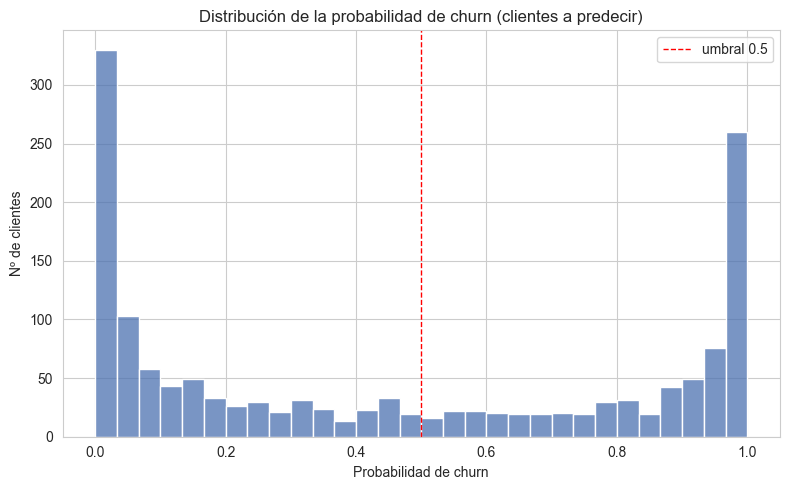

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(pred_proba, bins=30, color="#4c72b0")
plt.axvline(0.5, color="red", linestyle="--", linewidth=1, label="umbral 0.5")
plt.title("Distribución de la probabilidad de churn (clientes a predecir)")
plt.xlabel("Probabilidad de churn"); plt.ylabel("Nº de clientes"); plt.legend()
plt.tight_layout(); plt.show()

Los **20 clientes más propensos a fugarse** (mayor probabilidad): serían los primeros objetivos de una campaña de retención.

In [ ]:
display(pretty_table(resultado.sort_values("predict_proba", ascending=False).head(20).reset_index(drop=True), precision=4))

,customer_id,predict,predict_proba
0,"1,074,314",1,1.0000
1,"1,011,100",1,1.0000
2,"1,028,659",1,1.0000
3,"1,076,249",1,1.0000
4,"1,054,479",1,1.0000
5,"1,038,632",1,1.0000
6,"1,025,343",1,1.0000
7,"1,065,200",1,1.0000
8,"1,003,890",1,0.9999
9,"1,042,059",1,0.9999


In [ ]:
# comprobación: el archivo de predicción debe tener todas las filas originales
print("len del archivo de predicción:", len(resultado))
assert len(resultado) == len(df_predecir), "¡Faltan clientes en la predicción!"
print("OK: predicción sobre el 100% de los clientes.")

len del archivo de predicción: 1500
OK: predicción sobre el 100% de los clientes.


# 9. Exportar predicción

Exportamos un CSV con **exactamente 3 columnas en minúscula**: `customer_id`, `predict`, `predict_proba`.

In [ ]:
resultado = resultado[["customer_id", "predict", "predict_proba"]]
resultado.to_csv(RUTA / "churn_prediccion.csv", index=False)
print("Exportado", RUTA / "churn_prediccion.csv")
display(pretty_table(resultado.head(), precision=4))

Exportado churn_prediccion.csv


,customer_id,predict,predict_proba
0,"1,000,055",1,0.9995
1,"1,000,081",1,0.4597
2,"1,000,301",1,0.7824
3,"1,000,444",1,0.8421
4,"1,000,449",1,0.4728


---
### Conclusiones del entregable

1. **EDA** — el dataset está casi balanceado (55% se quedan / 45% se van), 8 columnas presentan nulos y `infobase` es constante.
2. **Preprocessing** — encapsulamos todo el preprocessing en un `Pipeline` de scikit-learn, ajustado exclusivamente con el train (nunca con test ni predict): imputación de nulos (mediana / `UNKNOWN`), One-Hot Encoding para las categóricas normales, **target encoding out-of-fold** para las tres de alta cardinalidad (`ethnic`, `area`, `crclscod`), y eliminación de alta correlación (>0.9) y baja varianza (<0.01). El pipeline ajustado queda guardado y es reutilizable sobre cualquier dataset nuevo con `pipeline.transform(...)`.
3. **Modelado** — realizamos una competición de modelos evaluada por f1-score; gana un modelo de boosting basado en árboles; lo hiperparametrizamos con GridSearch y lo validamos con validación cruzada.
4. **Evaluación** — obtenemos un AUC ~0.94 y un f1 ~0.85 en test, sin señales de sobreajuste relevante.
5. **Interpretabilidad** — combinamos los coeficientes del modelo lineal con los valores SHAP del modelo ganador; los principales drivers de la fuga (antigüedad del equipo, caída de uso) tienen sentido de negocio.
6. **Predicción y exportación** — generamos la predicción sobre el 100% de los clientes, identificamos el top-20 de mayor riesgo y exportamos el CSV final.

Con esto damos por completado el Entregable 2, cumpliendo con los puntos solicitados en el enunciado: EDA, preprocessing, modelado, evaluación, interpretabilidad y predicción sobre el dataset de 1.500 clientes.